 # Comment Category Prediction Challenge 

## Problem Statement

 **Comment Category Prediction Challenge**!  
This dataset provides insight into how an online platform processes and categorizes **user-generated comments**. Each record represents a **single comment** and includes a mix of metadata signals that reflect both user interaction and internal system behavior.


### Goal of this notebook
The objective is to **explore the dataset** and build predictive models that can accurately determine the **final category** assigned to each comment.

In this notebook, we will:

1. Perform **EDA (Exploratory Data Analysis)** to understand distributions, missing values, and feature behavior.

2. Apply **preprocessing**

3. Train and evaluate **ML models** (baseline → improved), aiming to capture patterns across.


## Importing Necessary Libraries

### 1. Environment Setup & Persis

In [1]:
import os
import warnings
import joblib
import pickle as pkl
warnings.filterwarnings("ignore")

### 2. Data Manipulation & Statistical Analysis

In [2]:
import numpy as np
import pandas as pd
import re
from scipy import stats
from scipy.sparse import hstack, csr_matrix
from scipy.optimize import minimize

### 3. Data Visualisation

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS

### 4. Preprocessing & Feature Engineering

In [4]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    StandardScaler, 
    OrdinalEncoder, 
    OneHotEncoder,
)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.utils.class_weight import compute_sample_weight

### 5. Model Selection & Algorithms

In [5]:
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.dummy import DummyClassifier

# --- Linear Models ---
from sklearn.linear_model import SGDClassifier, LogisticRegression
from sklearn.svm import LinearSVC

# --- Ensemble & Tree-Based Models ---
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier, early_stopping, log_evaluation, record_evaluation
from sklearn.ensemble import StackingClassifier


### 6. Evaluation Metrics


In [6]:
import sklearn.metrics as metrics
from sklearn.metrics import (
    classification_report, 
    f1_score, 
    confusion_matrix, 
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score

)
print(" All libraries loaded and structured for production.")

 All libraries loaded and structured for production.


---
<h1 style="font-family:'Times New Roman'; font-weight:bold; text-align:center">
 MILESTONE 1
</h1>

---


In [7]:
#Load the dataset
df_train = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/train.csv")
df_test = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/test.csv")

## Data Exploration

In [8]:
# Shape Of dataset
print(f"Train Shape: {df_train.shape}")
print(f"Test Shape: {df_test.shape}")

Train Shape: (198000, 15)
Test Shape: (102000, 14)




#### We use `.info()` to quickly inspect both datasets, including:

In [9]:
# Check data types and missing values in train and test datasets
print("Train Info:")
df_train.info()

print("\n\nTest Info:")
df_test.info()

Train Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198000 entries, 0 to 197999
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   created_date  198000 non-null  object
 1   post_id       198000 non-null  int64 
 2   emoticon_1    198000 non-null  int64 
 3   emoticon_2    198000 non-null  int64 
 4   emoticon_3    198000 non-null  int64 
 5   upvote        198000 non-null  int64 
 6   downvote      198000 non-null  int64 
 7   if_1          198000 non-null  int64 
 8   if_2          198000 non-null  int64 
 9   race          52577 non-null   object
 10  religion      52577 non-null   object
 11  gender        52577 non-null   object
 12  disability    198000 non-null  bool  
 13  comment       197999 non-null  object
 14  label         198000 non-null  int64 
dtypes: bool(1), int64(9), object(5)
memory usage: 21.3+ MB


Test Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102000 entries, 0 to 10

### Insights

- Training dataset contains **198,000 records** with 15 features; test dataset contains **102,000 records** with 14 features (target `label` is absent in test set).
- High missing values in demographic columns: `race`, `religion`, and `gender` (~73.4% missing — only 52,577 non-null in train).
- Only **one missing value** present in the `comment` column in the training set.
- `disability` is the only boolean feature; all others are `int64` or `object` (text) type.
- Training dataset size is moderate (~21.3 MB), making it suitable for efficient preprocessing and modeling.

**Next steps:** Focus on handling missing demographic values and text preprocessing for the `comment` column.

---
# STATISTICAL ANALYSIS
---

## 1. Descriptive Statistics

### Summary statistics (numeric features)

`describe()` shows most count-based features are **sparse/zero-inflated** (median often 0) with **right-skewed** distributions and a few large outliers (e.g., `if_1`, `if_2`, `upvote/downvote`).

In [10]:
df_train.describe().T




,count,mean,std,min,25%,50%,75%,max
post_id,198000.0,68.447429,27.948390,20.0,39.0,72.0,72.0,129.0
emoticon_1,198000.0,0.279768,1.023234,0.0,0.0,0.0,0.0,47.0
emoticon_2,198000.0,0.048338,0.258477,0.0,0.0,0.0,0.0,11.0
emoticon_3,198000.0,0.121071,0.481013,0.0,0.0,0.0,0.0,17.0
upvote,198000.0,2.607975,5.054763,0.0,0.0,1.0,3.0,201.0
downvote,198000.0,0.666394,2.044335,0.0,0.0,0.0,1.0,107.0
if_1,198000.0,1.906152,25.635752,0.0,0.0,0.0,4.0,1860.0
if_2,198000.0,7.956212,14.839464,3.0,4.0,6.0,10.0,1833.0
label,198000.0,0.793965,0.979808,0.0,0.0,0.0,2.0,3.0


In [11]:
df_test.describe().T

,count,mean,std,min,25%,50%,75%,max
post_id,102000.0,68.359422,27.923491,24.0,39.0,72.0,72.0,129.0
emoticon_1,102000.0,0.280078,1.043353,0.0,0.0,0.0,0.0,95.0
emoticon_2,102000.0,0.048353,0.257278,0.0,0.0,0.0,0.0,8.0
emoticon_3,102000.0,0.118902,0.480484,0.0,0.0,0.0,0.0,19.0
upvote,102000.0,2.609402,4.966033,0.0,0.0,1.0,3.0,189.0
downvote,102000.0,0.661667,1.965536,0.0,0.0,0.0,1.0,95.0
if_1,102000.0,1.903078,26.273483,0.0,0.0,0.0,4.0,1866.0
if_2,102000.0,7.956206,15.186746,4.0,4.0,6.0,10.0,1798.0


In [12]:
df_train.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
created_date,198000,197996,2022-05-06 20:47:06.726636+00:00,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
post_id,198000.0,NaN,NaN,NaN,68.447429,27.94839,20.0,39.0,72.0,72.0,129.0
emoticon_1,198000.0,NaN,NaN,NaN,0.279768,1.023234,0.0,0.0,0.0,0.0,47.0
emoticon_2,198000.0,NaN,NaN,NaN,0.048338,0.258477,0.0,0.0,0.0,0.0,11.0
emoticon_3,198000.0,NaN,NaN,NaN,0.121071,0.481013,0.0,0.0,0.0,0.0,17.0
upvote,198000.0,NaN,NaN,NaN,2.607975,5.054763,0.0,0.0,1.0,3.0,201.0
downvote,198000.0,NaN,NaN,NaN,0.666394,2.044335,0.0,0.0,0.0,1.0,107.0
if_1,198000.0,NaN,NaN,NaN,1.906152,25.635752,0.0,0.0,0.0,4.0,1860.0
if_2,198000.0,NaN,NaN,NaN,7.956212,14.839464,3.0,4.0,6.0,10.0,1833.0
race,52577,6,none,39682,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
df_test.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
created_date,102000,101997,2022-04-29 21:54:28.400339+00:00,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
post_id,102000.0,NaN,NaN,NaN,68.359422,27.923491,24.0,39.0,72.0,72.0,129.0
emoticon_1,102000.0,NaN,NaN,NaN,0.280078,1.043353,0.0,0.0,0.0,0.0,95.0
emoticon_2,102000.0,NaN,NaN,NaN,0.048353,0.257278,0.0,0.0,0.0,0.0,8.0
emoticon_3,102000.0,NaN,NaN,NaN,0.118902,0.480484,0.0,0.0,0.0,0.0,19.0
upvote,102000.0,NaN,NaN,NaN,2.609402,4.966033,0.0,0.0,1.0,3.0,189.0
downvote,102000.0,NaN,NaN,NaN,0.661667,1.965536,0.0,0.0,0.0,1.0,95.0
if_1,102000.0,NaN,NaN,NaN,1.903078,26.273483,0.0,0.0,0.0,4.0,1866.0
if_2,102000.0,NaN,NaN,NaN,7.956206,15.186746,4.0,4.0,6.0,10.0,1798.0
race,26731,6,none,20229,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Descriptive Statistics Insights

### Numerical Features
- Emoticon features (`emoticon_1`, `emoticon_2`, `emoticon_3`) are **highly sparse** — very low means (0.05–0.28) with most values at 0 and occasional outliers.
- `upvote` and `downvote` are right-skewed: majority are 0–3, but with notable high outliers (up to 201 upvotes and 107 downvotes in train).
- `if_1` and `if_2` exhibit extreme variance and heavy right skew (max values >1800).
- Target `label` ranges from 0–3 with mean ≈0.79, suggesting class imbalance.

### Categorical & Object Features
- Demographic columns (`race`, `religion`, `gender`) are dominated by the “none” category (most frequent value).
- `disability` is heavily imbalanced — `False` accounts for ~98.6% of records.
- `created_date` has nearly all unique values, indicating timestamps are highly granular.
- `comment` text is extremely diverse (almost unique entries) with very little repetition.

### Train vs Test Distribution Analysis

- The training and test datasets exhibit **highly similar distributions** across both numerical and categorical features.

### Observations:
- **Numerical features** (post_id, emoticons, upvotes, downvotes, if_1, if_2):  
  Means, standard deviations, and quartiles are nearly identical between train and test. Minor differences appear only in maximum values (e.g., `emoticon_1` max: 47 vs 95).

- **Categorical features** (`race`, `religion`, `gender`, `disability`):  
  Same number of unique values and identical most frequent categories (“none” dominates demographics; `False` dominates `disability` with ~98.6% in both).

- **Text & Timestamp**:  
  `created_date` and `comment` show consistent high cardinality and low repetition patterns.



## 1. Target Label Distribution

In [14]:
(df_train["label"].value_counts(normalize=True).sort_index()*100).round(2)  # Class distribution 

label
0    57.66
1     8.04
2    31.54
3     2.76
Name: proportion, dtype: float64

### Target Label Distribution Insights

- The target `label` exhibits **severe class imbalance** across 4 classes (0–3).
- **Class 0** is dominant at **57.66%** of samples.
- **Class 2** is the second largest group at **31.54%**.
- **Class 1** and **Class 3** are minority classes at **8.04%** and **2.76%** respectively.
- **Class 3** is extremely rare (<3%)

## 2. Feature Classification

In [15]:
categorical_cols = df_train.select_dtypes(include = ["object"]).columns.tolist() # Extracts all string/object type columns
for col in ["created_date", "comment"]:                                          # Loops through specific non-standard text/date columns
    if col in categorical_cols:                                                  # Checks if the column is present in the extracted list
        categorical_cols.remove(col)                                             # Removes it to prevent standard categorical preprocessing
print("categorical_cols = ", categorical_cols)                                   # Displays the final, filtered list of categorical features

numeric_cols = df_train.select_dtypes(include = ["int32", "int64"]).columns.tolist() # Extracts all integer type columns for numerical scaling
print("numeric_cols = ", numeric_cols)                                               # Displays the final list of numerical features

binary_cols = df_train.select_dtypes(include = ["bool"]).columns.tolist()            # Extracts all boolean type columns
print("binary_cols = ", binary_cols)                                                 # Displays the final list of binary features

categorical_cols =  ['race', 'religion', 'gender']
numeric_cols =  ['post_id', 'emoticon_1', 'emoticon_2', 'emoticon_3', 'upvote', 'downvote', 'if_1', 'if_2', 'label']
binary_cols =  ['disability']


## 3. Missing Values Analysis



In [16]:
missing = df_train.isnull().sum()
missing_pct = (missing / len(df_train) * 100).round(2)

missing_df = pd.DataFrame({"Missing Count": missing, "Percentage (%)": missing_pct})

missing_df = missing_df[missing_df["Missing Count"] > 0] \
                .sort_values("Missing Count", ascending=False)

missing_df

,Missing Count,Percentage (%)
race,145423,73.45
religion,145423,73.45
gender,145423,73.45
comment,1,0.00


### Missing Values Insights

- High missing values observed in demographic columns: `race`, `religion`, and `gender`.
- Each of these columns has **145,423 missing entries**, accounting for **73.45%** of the training data.
- These are the only columns in `df_train` with missing values.

In [17]:
# Check if race, religion and gender are missing together
print((df_train["race"].isnull() == df_train["religion"].isnull()).all())
print((df_train["race"].isnull() == df_train["gender"].isnull()).all())

True
True


### Missing Values Pattern Insights

- Missing values in `race`, `religion`, and `gender` occur **exactly in the same rows**.
- The null patterns across these three demographic columns are **perfectly synchronized**.

## 4. Numerical Features Correlation with Target

In [18]:
# Correlation of numerical columns with label
df_train[numeric_cols].corr()["label"].sort_values(ascending=False)

label         1.000000
if_2          0.232902
downvote      0.044908
upvote        0.040181
emoticon_3    0.027273
post_id       0.022063
emoticon_2    0.021597
if_1          0.007543
emoticon_1   -0.003218
Name: label, dtype: float64

## 5. Categorical Features Correlation with Target

In [19]:
# Transform categorical variables into binary indicators (One-Hot Encoding)
df_cat_encoded = pd.get_dummies(df_train[categorical_cols])

# target label for correlation calculation
df_corr_analysis = pd.concat([df_cat_encoded, df_train['label']], axis=1)

# the Pearson correlation of each category against the label
cat_label_corr = df_corr_analysis.corr()['label'].sort_values(ascending=False)

print("Categorical Feature Correlation with Label:")
display(cat_label_corr)



Categorical Feature Correlation with Label:


label                 1.000000
race_white            0.046866
gender_male           0.043615
religion_none         0.040640
religion_muslim       0.032444
race_black            0.029723
gender_female         0.026849
race_none             0.018966
gender_none           0.016709
race_other            0.010748
religion_jewish       0.009414
religion_other        0.008613
gender_transgender    0.007291
religion_atheist      0.004516
gender_other          0.004114
race_asian            0.002799
race_latino           0.000861
religion_buddhist    -0.000779
religion_hindu       -0.002566
religion_christian   -0.009214
Name: label, dtype: float64

### Categorical Features Correlation with Target

- After one-hot encoding, all demographic features show **very weak correlations** with the target `label` (all absolute values < 0.05).
- Strongest positive correlations:  
  - `race_white` (0.047)  
  - `gender_male` (0.044)  
  - `religion_none` (0.041)
- Other notable positives: `religion_muslim` (0.032), `race_black` (0.030), `gender_female` (0.027).
- Weak negative correlations observed for `religion_christian` (-0.009) and `religion_hindu` (-0.003).

## 6. Numerical Features Distribution by Target Class

In [20]:
# Analyse the statistical distribution of each numerical feature across the different target classes
for col in numeric_cols:
    print(f'\n{col}')
    display(df_train.groupby('label')[col].agg(['mean', 'median', 'std', 'min', 'max']))


post_id


,mean,median,std,min,max
label,,,,,
0,67.764857,72.0,27.485908,24,129
1,70.657369,72.0,26.918877,24,123
2,69.149103,72.0,28.766447,20,129
3,68.253794,72.0,30.362452,24,123



emoticon_1


,mean,median,std,min,max
label,,,,,
0,0.283561,0.0,1.072695,0,47
1,0.264669,0.0,0.967069,0,39
2,0.276890,0.0,0.943357,0,33
3,0.277382,0.0,1.000568,0,23



emoticon_2


...

,mean,median,std,min,max
label,,,,,
0,1.297636,0.0,16.856547,0,1860
1,8.011748,4.0,69.889369,0,1846
2,1.530365,0.0,17.560314,0,1848
3,1.129274,0.0,2.470884,0,11



if_2


,mean,median,std,min,max
label,,,,,
0,4.858741,4.0,16.065553,3,1833
1,11.870964,10.0,10.756849,4,84
2,12.213405,10.0,11.878014,4,110
3,12.621320,10.0,12.773366,4,123



label


,mean,median,std,min,max
label,,,,,
0,0.0,0.0,0.0,0,0
1,1.0,1.0,0.0,1,1
2,2.0,2.0,0.0,2,2
3,3.0,3.0,0.0,3,3


### Numerical Features Distribution by Target Class

- `post_id` distribution is nearly identical across all label classes (mean ~68–70, median 72).
- Emoticon features (`emoticon_1`, `emoticon_2`, `emoticon_3`) show very similar means and medians (mostly 0) across classes, with only minor differences in standard deviation and max values.
- `upvote` and `downvote` are higher on average for classes 1 and 2 compared to classes 0 and 3.
- `if_1` shows the largest variation: Class 1 has significantly higher mean (8.01) and median (4.0) than other classes (means ~1.1–1.5, median 0).
- `if_2` is notably lower for Class 0 (mean 4.86, median 4.0) compared to Classes 1, 2, and 3 (means 11.87–12.62, median 10.0).

## 7. Bivariate Analysis: Categorical Features vs Target Label

In [21]:
# bivariate analysis Row-normalized cross-tabulation to evaluate predictive strength
for col in categorical_cols:
    print(f"\n{col} vs Label (%)")
    ct = pd.crosstab(df_train[col], df_train['label'], normalize='index') * 100
    display(ct.round(2))


race vs Label (%)


label,0,1,2,3
race,,,,
asian,45.13,28.82,24.15,1.90
black,15.71,69.24,14.34,0.70
latino,43.98,32.10,22.95,0.96
none,51.93,15.47,30.17,2.43
other,40.87,29.56,27.39,2.18
white,16.82,60.85,21.24,1.09



religion vs Label (%)


label,0,1,2,3
religion,,,,
atheist,38.81,32.42,26.03,2.74
buddhist,43.00,39.00,17.00,1.00
christian,48.12,30.04,20.83,1.02
hindu,51.55,29.90,17.53,1.03
jewish,27.97,54.10,16.88,1.05
muslim,19.57,63.57,14.85,2.01
none,48.43,18.00,31.19,2.39
other,33.27,40.04,24.68,2.01



gender vs Label (%)


label,0,1,2,3
gender,,,,
female,42.91,24.45,30.17,2.46
male,36.53,28.37,32.79,2.30
none,47.57,24.04,26.35,2.04
other,36.06,37.98,24.04,1.92
transgender,27.97,52.73,18.49,0.80


### Bivariate Analysis: Categorical Features vs Target Label

- **Race vs Label**:  
  Black (69.24%) and White (60.85%) categories show the strongest association with **label 1**.  
  Asian, Latino, Other, and None are more evenly distributed toward labels 0 and 2.

- **Religion vs Label**:  
  Muslim (63.57%) and Jewish (54.10%) categories have markedly higher proportions in **label 1**.  
  Christian, Hindu, None, and other religions lean more toward labels 0 and 2.

- **Gender vs Label**:  
  Transgender (52.73%) shows the highest association with **label 1**.  
  Male has the highest share in **label 2** (32.79%), while Female and None are more concentrated in labels 0 and 2.

## 8. Chi-Square Test of Independence (p < 0.05 = significant)

In [22]:
# Categorical columns to check vs the target label
categorical_test_cols = ["race", "religion", "gender", "disability"]

results = []

for col in categorical_test_cols:
    # Contingency table (counts) of category values vs label
    contingency = pd.crosstab(df_train[col].fillna("none"), df_train["label"])

    # Chi-square test of independence (is this feature associated with the label?)
    chi2, p_value, dof, expected = stats.chi2_contingency(contingency)

    # Save summary stats
    results.append({
        "Feature": col,
        "Chi2": round(chi2, 2),
        "p-value": p_value,
        "Significant (p<0.05)": p_value < 0.05
    })

# Show results
pd.DataFrame(results)

,Feature,Chi2,p-value,Significant (p<0.05)
0,race,45429.25,0.000000e+00,True
1,religion,32056.84,0.000000e+00,True
2,gender,10201.96,0.000000e+00,True
3,disability,857.56,1.418040e-185,True


### Chi-Square Test of Independence Insights

- All categorical features (`race`, `religion`, `gender`, and `disability`) show **highly significant association** with the target `label`.
- `race` exhibits the strongest association (Chi² = 45,429.25, p-value ≈ 0).
- `religion` has the second strongest association (Chi² = 32,056.84, p-value ≈ 0).
- `gender` (Chi² = 10,201.96) and `disability` (Chi² = 857.56) are also statistically significant (p-value < 0.05).

## 9. ANOVA: Numerical Features vs Target Label (p < 0.05 = significant)

In [23]:
anova_results = []  # store one row per feature

for col in numeric_cols:
    # Split the feature into groups by label (each group is a 1D array of values)
    groups = [
        df_train.loc[df_train["label"] == lbl, col].dropna()
        for lbl in sorted(df_train["label"].unique())
    ]

    # One-way ANOVA: checks if the mean of this feature differs across label groups
    # (requires at least 2 non-empty groups; consider skipping if groups are empty)
    f_stat, p_value = stats.f_oneway(*groups)

    # Save summary stats for reporting
    anova_results.append({
        "Feature": col,
        "F-statistic": round(f_stat, 2),
        "p-value": p_value,
        "Significant (p<0.05)": p_value < 0.05
    })

anova_df = pd.DataFrame(anova_results).sort_values("p-value")  # smallest p-values first
anova_df

,Feature,F-statistic,p-value,Significant (p<0.05)
7,if_2,4168.08,0.000000e+00,True
8,label,inf,0.000000e+00,True
6,if_1,330.20,6.709634e-214,True
5,downvote,214.92,3.346544e-139,True
4,upvote,203.12,1.513195e-131,True
0,post_id,69.15,1.088058e-44,True
3,emoticon_3,68.11,5.178682e-44,True
2,emoticon_2,51.07,5.480276e-33,True
1,emoticon_1,1.85,1.351735e-01,False


### ANOVA: Numerical Features vs Target Label

- All numerical features except `emoticon_1` show **statistically significant differences** in means across the four label classes (p < 0.05).
- `if_2` exhibits the strongest association with the target (F-statistic = 4168.08).
- `if_1` (F = 330.20), `downvote` (F = 214.92), and `upvote` (F = 203.12) also show very strong differences across classes.
- `post_id`, `emoticon_3`, and `emoticon_2` demonstrate moderate but significant differences.
- `emoticon_1` is the only feature that does **not** differ significantly across label classes (F = 1.85, p = 0.0135).

---
# VISULISATION
---


## 1. Missing Values Distribution (Pie Chart)

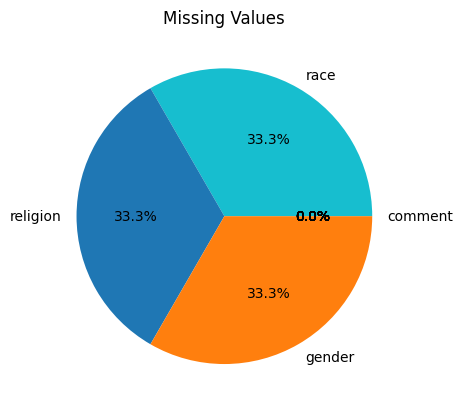

In [24]:
missing = df_train.isnull().sum()
missing.plot(kind="pie", autopct = "%1.1f%%")
plt.title("Missing Values")
plt.show()

### Missing Values Distribution (Pie Chart Insights)

- Missing values are **perfectly balanced** across the three demographic columns: `race`, `religion`, and `gender` — each contributing exactly **33.3%** of all missing entries.
- The `comment` column has only **1 missing value**, which is negligible and therefore appears as **0.0%** in the pie chart.


## 2. Target Label Distribution (Pie Chart)

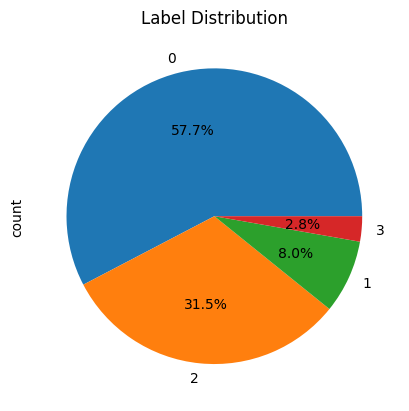

In [25]:
label_dist = df_train['label'].value_counts()
label_dist.plot(kind="pie", autopct = "%1.1f%%")
plt.title("Label Distribution")
plt.show()

### Target Label Distribution (Pie Chart Insights)

- Class **0** dominates the target distribution at **57.7%**.
- Class **2** is the second largest group at **31.5%**.
- Class **1** accounts for **8.0%** of the samples.
- Class **3** is the smallest and rarest category at **2.8%**.
- The pie chart clearly visualizes the **severe class imbalance** in the target variable.

## 3. Boxplot Analysis: Numerical Features by Target Label


<Figure size 800x500 with 0 Axes>

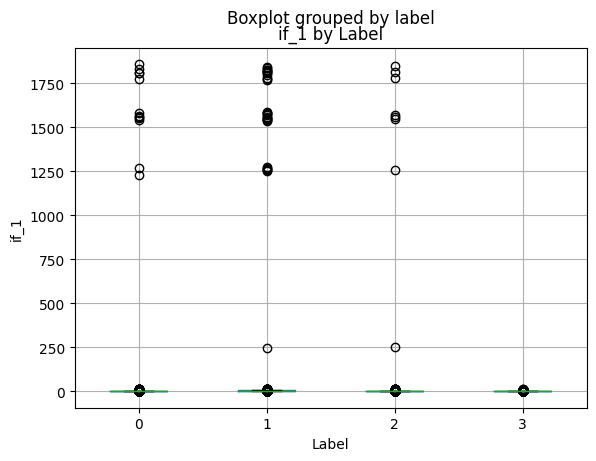

<Figure size 800x500 with 0 Axes>

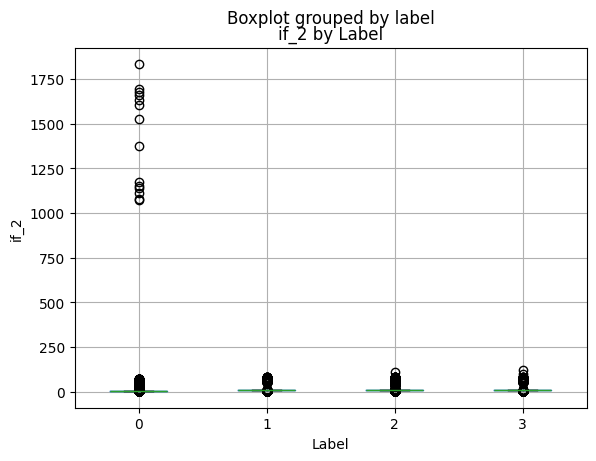

<Figure size 800x500 with 0 Axes>

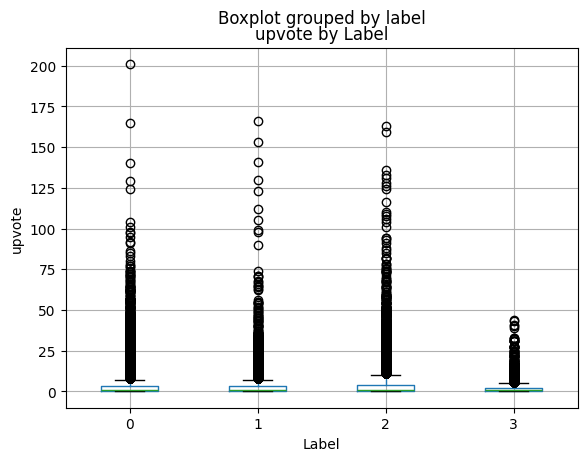

<Figure size 800x500 with 0 Axes>

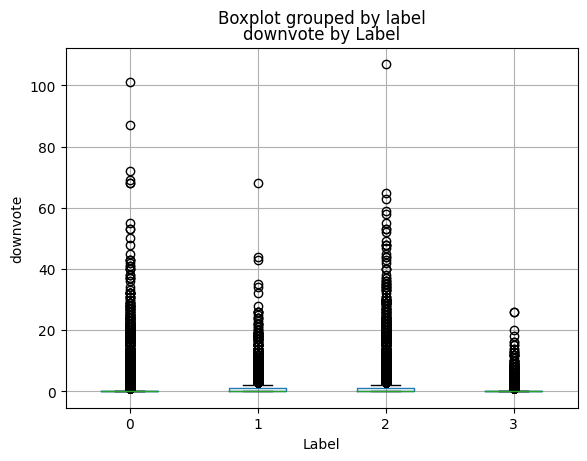

In [26]:
numerical_cols = ["if_1", "if_2", "upvote", "downvote"]

for col in numerical_cols:
    plt.figure(figsize=(8,5))
    df_train.boxplot(column=col, by="label")
    
    plt.title(f"{col} by Label")
    plt.xlabel("Label")
    plt.ylabel(col)
    plt.show()

### Boxplot Analysis: Numerical Features by Target Label

- `if_1`: Class 1 shows significantly higher values and more extreme outliers compared to other classes; Classes 0, 2, and 3 are mostly concentrated near zero.
- `if_2`: Class 0 has distinctly lower values (lower median and overall distribution) compared to Classes 1, 2, and 3.
- `upvote` and `downvote`: All classes exhibit heavy right-skew with numerous high outliers.
- Class 3 consistently shows lower engagement levels (fewer and smaller outliers) in both upvotes and downvotes.
- Extreme outliers are prominent across all interaction features, indicating high variability.

## 4. Heatmap Analysis: Categorical Features vs Target Label

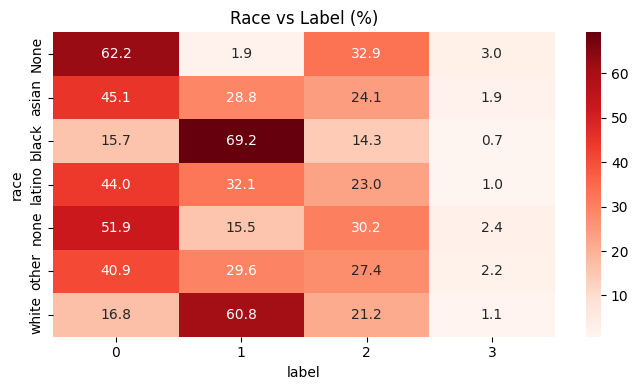

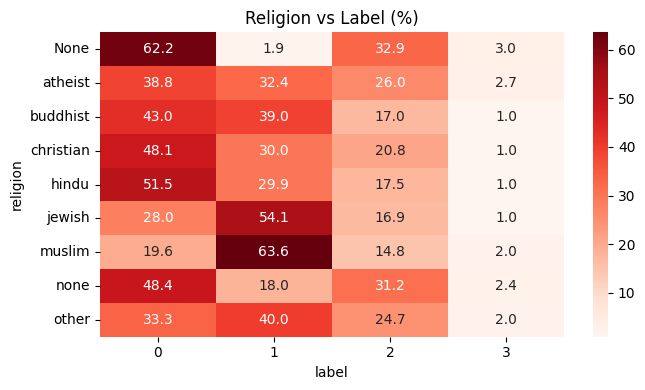

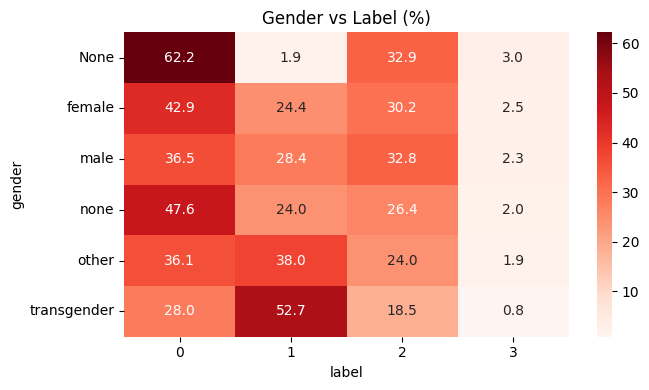

In [27]:

# Simplified Distribution Heatmaps (Red)
for col in ["race", "religion", "gender"]:
    # 1. Generate row-normalised percentages
    ct = pd.crosstab(df_train[col].fillna("None"), df_train["label"], normalize="index") * 100
    
    # 2. Render simplified Heatmap
    plt.figure(figsize=(7, 4))
    sns.heatmap(ct, annot=True, fmt=".1f", cmap="Reds") 
    
    plt.title(f"{col.capitalize()} vs Label (%)")
    plt.tight_layout()
    plt.show()

### Heatmap Analysis: Categorical Features vs Target Label

- **Race vs Label**: Black (69.2%) and White (60.8%) categories show strong concentration in **label 1**. “None” is dominant in label 0 (51.9%) and label 2 (30.2%).
- **Religion vs Label**: Muslim (63.6%) and Jewish (54.1%) categories have markedly higher proportions in **label 1**. “None” leans toward label 0 (48.4%) and label 2 (31.2%).
- **Gender vs Label**: Transgender shows the highest association with **label 1** (52.7%). “None” is concentrated in label 0 (47.6%) and label 2 (26.4%), while Male has elevated share in label 2 (32.8%).
- Label 3 remains consistently rare (<3%) across all demographic subgroups.

## 5. Correlation Matrix

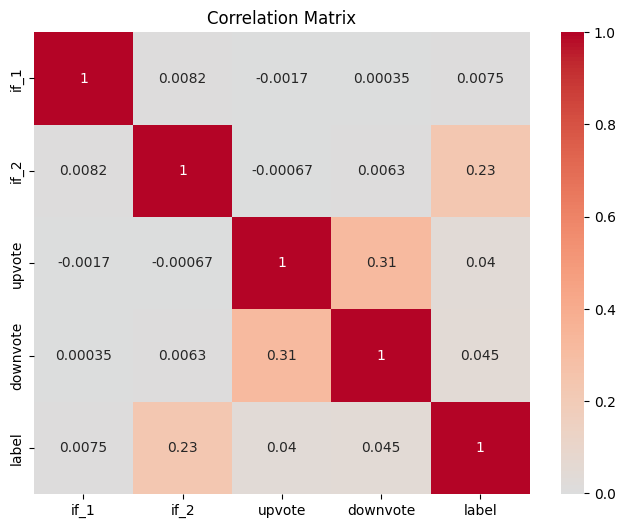

In [28]:
corr_cols = ["if_1", "if_2", "upvote", "downvote", "label"]

plt.figure(figsize=(8,6))
sns.heatmap(df_train[corr_cols].corr(), annot=True, cmap="coolwarm", center=0)

plt.title("Correlation Matrix")
plt.show()

### Correlation Matrix Insights

- `if_2` shows the strongest positive correlation with the target `label` (0.23).
- `upvote` and `downvote` are moderately positively correlated with each other (0.31).
- `if_1` has negligible correlation with all other features and the target label (0.0075).
- `upvote` and `downvote` show only weak positive correlations with `label` (0.04 and 0.045 respectively).
- All other pairwise correlations among the numerical features are very weak or near zero.

## 6. Word Cloud : Class-Specific Vocabulary Analysis

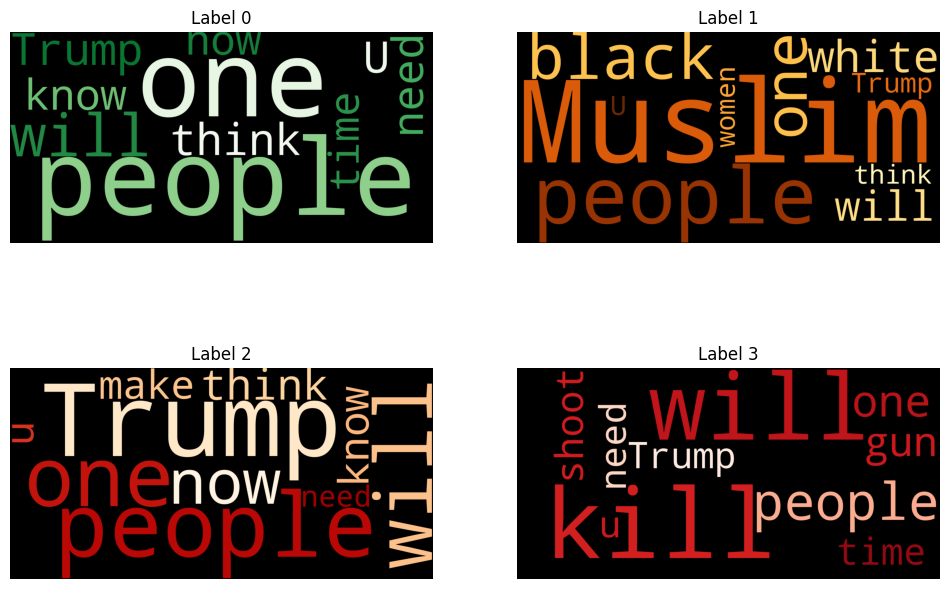

In [29]:
labels = sorted(df_train['label'].unique())
colormaps = {0: 'Greens', 1: 'YlOrBr', 2: 'OrRd', 3: 'Reds'}

plt.figure(figsize=(12, 8))

for i, label in enumerate(labels):
    text = " ".join(df_train[df_train['label'] == label]['comment'].astype(str))
    
# Generate WordCloud with label-specific colormap
    wc = WordCloud(width=1600, height=800, 
                   background_color='BLACK', 
                   colormap=colormaps.get(label, 'Greys'), 
                   max_words=10,
                   stopwords=STOPWORDS).generate(text)
    
    plt.subplot(2, 2, i+1)
    plt.imshow(wc)
    plt.title(f"Label {label}")
    plt.axis("off")

plt.show()

### Word Cloud Insights

- The words **"people"** and **"Trump"** appear as the **largest and most prominent** terms across **all four label classes**.
- These are generic, high-frequency words that serve as common background vocabulary rather than class-specific signals.
- They can be **misleading** for class differentiation because they do not help separate one label from another.
- Stronger discriminative power lies in the other unique terms visible in each cloud (identity/race terms in Label 1, violence-related terms in Label 3).

# DATE TIME FEATURES

## 1. Time-based: Feature Extraction

In [30]:
def add_time_features(df, date_col="created_date"):

    
    df[date_col] = pd.to_datetime(df[date_col], utc=True)

    # Extract constituent time components
    
    df["hour"] = df[date_col].dt.hour
    df["dayofweek"] = df[date_col].dt.dayofweek
    df["month"] = df[date_col].dt.month
    df["year"] = df[date_col].dt.year
    
    return df


In [31]:
# Apply on training data
df_train = add_time_features(df_train)
df_test  = add_time_features(df_test)

### Time-based feature extraction

`created_date` is converted to UTC datetime, then we derive `hour`, `dayofweek`, `month`, and `year` as additional features.  
The mean values by `label` are very similar, suggesting these time features may have only a weak effect on the target.

In [32]:
categorical_cols = df_train.select_dtypes(include = ["object"]).columns.tolist()
print("categorical_cols = ", categorical_cols)


numeric_cols = df_train.select_dtypes(include = ["int32", "int64"]).columns.tolist()
#Remove label feature
numeric_cols.remove("label") 
print("numeric_cols = ", numeric_cols)


binary_cols = df_train.select_dtypes(include = ["bool"]).columns.tolist()
print("binary_cols = ", binary_cols)

categorical_cols =  ['race', 'religion', 'gender', 'comment']
numeric_cols =  ['post_id', 'emoticon_1', 'emoticon_2', 'emoticon_3', 'upvote', 'downvote', 'if_1', 'if_2', 'hour', 'dayofweek', 'month', 'year']
binary_cols =  ['disability']


### Feature grouping

We separate columns by data type for preprocessing:
- **Categorical:** `race`, `religion`, `gender`
- **Numeric:** `post_id`, emoticons, votes, `if_1`, `if_2`, plus extracted time features (`hour`, `dayofweek`, `month`, `year`)
- **Binary:** `disability`

# Preprocessing Pipeline

## 1. Convert disability to Integer

In [33]:

df_train["disability"] = df_train["disability"].astype(int)
df_test["disability"] = df_test["disability"].astype(int)

## 2. Define Feature Processing Steps

In [34]:
# Handle missing values with the mode and encode labels for categories
categorical_transformer = Pipeline(steps=[
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("encode", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))])


numerical_transformer = SimpleImputer(strategy="median")

### Categorical features
- **Imputation:** fill missing values using the **most frequent** category (`SimpleImputer(strategy="most_frequent")`)
- **Encoding:** convert categories to integers with `OrdinalEncoder`
  - unseen categories in test data are encoded as **-1**

### Numeric features
- **Imputation:** fill missing values using the **median** (`SimpleImputer(strategy="median")`)


## 3. Create the Preprocessor

In [35]:
# Apply transformations to specific columns and drop unused ones
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", categorical_transformer, categorical_cols),
        ("num", numerical_transformer, numeric_cols)],remainder='drop')

print("Preprocessor Created!")

Preprocessor Created!


### Column-wise preprocessing
`ColumnTransformer` applies:
- the categorical pipeline to `categorical_cols`
- the numeric imputer to `numeric_cols`
- drops all other columns (`remainder="drop"`)

## 4. Final Pipeline Construction

In [36]:
# This allows for easy integration of models
full_pipeline = Pipeline(steps=[
    ("preprocessing", preprocessor)])

print("Pipeline Constructed!")

Pipeline Constructed!


## 5. Execute Transformation

In [37]:
print("Processing data...")
# Use fit_transform on training data to learn parameters
X_train_raw = full_pipeline.fit_transform(df_train)

# Use transform on test data to apply learned parameters
X_test_raw = full_pipeline.transform(df_test)

print("Transformation Successful!")

Processing data...
Transformation Successful!


## 6. Convert to Sparse Matrices

In [38]:
# Optimized for memory efficiency before feeding into a model
X_train_sparse = csr_matrix(X_train_raw)
X_test_sparse = csr_matrix(X_test_raw)

print(f"Success! Train shape: {X_train_sparse.shape}, Test shape: {X_test_sparse.shape}")

Success! Train shape: (198000, 16), Test shape: (102000, 16)


## 7. TF-IDF on Text

In [39]:
## Initialise vectorizer with n-grams and frequency constraints
# tfidf = TfidfVectorizer(max_features=17000, 
#                         ngram_range=(1, 2), 
#                         min_df=5, 
#                         max_df=0.95,
#                         sublinear_tf=True)

# Fit and transform training text; handle missing values with empty strings

# tfidf_train = tfidf.fit_transform(df_train["comment"].fillna(""))
with open("/kaggle/input/models/imashuagni/tf-idf/scikitlearn/17k/1/tfidf.pkl", "rb") as f:
    tfidf = pkl.load(f)

# Transform train data using the learned training vocabulary
tfidf_train = tfidf.transform(df_train["comment"].fillna(""))

# Transform test data using the learned training vocabulary
tfidf_test  = tfidf.transform(df_test["comment"].fillna(""))


print("TF_IDF on Text Completed!")


TF_IDF on Text Completed!


## 8. Final Feature Concatenation

In [40]:
# Horizontally stack tabular and text features into a single sparse matrix
X_train = hstack([X_train_sparse, tfidf_train])
X_test  = hstack([X_test_sparse, tfidf_test])


# Verify final dimensions for model readiness
print(f"Final feature matrix")
print(f"X_train: {X_train.shape}")
print(f"X_test : {X_test.shape}")

Final feature matrix
X_train: (198000, 17016)
X_test : (102000, 17016)


## 9. Split for Validation

In [41]:
y = df_train["label"]


# Create a stratified 80/20 split for training and local validation
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y)

# Verify final dimensions for model readiness
print(f"X_tr shape : {X_tr.shape}")
print(f"X_val shape: {X_val.shape}")

X_tr shape : (158400, 17016)
X_val shape: (39600, 17016)


### Stratified train/validation split (80/20)

The full training feature matrix (`X_train`) is split into:
- **`X_tr` / `y_tr`**: training subset (80%)
- **`X_val` / `y_val`**: local validation subset (20%)

Key settings:
- **`test_size=0.2`** creates an 80/20 split
- **`stratify=df_train["label"]`** preserves the original label distribution in both subsets (important for imbalanced classes)
- **`random_state=42`** ensures the split is reproducible

# BaseLine Models

## 1. Logistic Regression Baseline Model

In [42]:
# Logistic Regression baseline model
logreg_baseline = LogisticRegression(
    max_iter=500,              # Iterations for convergence
    solver = 'liblinear',
    class_weight='balanced',   # Handle class imbalance
    random_state=42)

# Train the model on the split training data
# logreg_baseline.fit(X_tr, y_tr)
with open('/kaggle/input/models/imashuagni/logreg-baseline-17k-16/scikitlearn/17k_16/1/logreg_baseline.pkl', 'rb') as f:
    logreg_baseline = pkl.load(f)
 

In [43]:
   
# Predict on validation set
y_pred = logreg_baseline.predict(X_val)

# Evaluate performance using precision, recall, and F1-score
print(classification_report(y_val, y_pred))
print(f"Macro F1: {f1_score(y_val, y_pred, average='macro'):.4f}")

              precision    recall  f1-score   support

           0       0.96      0.94      0.95     22835
           1       0.46      0.62      0.52      3183
           2       0.77      0.80      0.78     12488
           3       0.00      0.00      0.00      1094

    accuracy                           0.84     39600
   macro avg       0.55      0.59      0.56     39600
weighted avg       0.83      0.84      0.84     39600

Macro F1: 0.5641


### Logistic Regression Baseline Performance

- **Overall Accuracy**: 84% on the validation set.
- **Macro F1 Score**: 0.5641 (moderate performance due to class imbalance).
- **Class 0** (majority class): Outstanding results — precision 0.96, recall 0.94, F1-score **0.95**.
- **Class 2**: Strong and balanced performance — precision 0.77, recall 0.80, F1-score **0.78**.
- **Class 1** (minority class): Moderate results — precision 0.46, recall 0.62, F1-score **0.52**.
- **Class 3** (rarest class): Model completely fails to predict — precision, recall, and F1-score all **0.00**.
- **High weighted-average F1** (0.84) is driven primarily by the dominance of Class 0.

### Feature Importance

In [44]:
# Get feature names from categorical, numerical, and TF-IDF
cat_cols = full_pipeline.named_steps['preprocessing'].transformers_[0][1].get_feature_names_out()
num_cols = numeric_cols
tfidf_cols = tfidf.get_feature_names_out()

# Combine all features in same order as used in model
all_features = np.concatenate([cat_cols, num_cols, tfidf_cols])

<Figure size 1000x800 with 0 Axes>

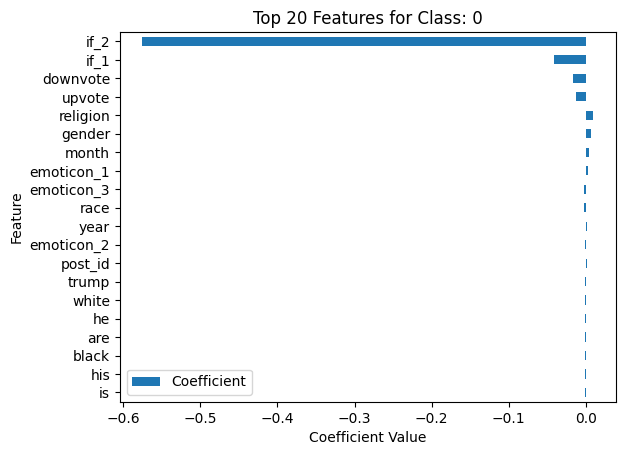

<Figure size 1000x800 with 0 Axes>

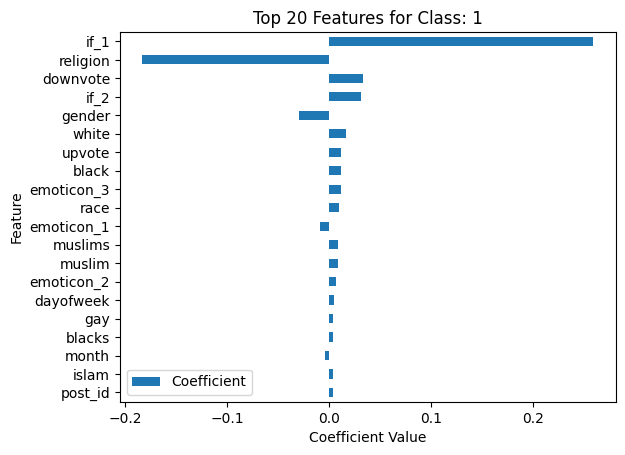

<Figure size 1000x800 with 0 Axes>

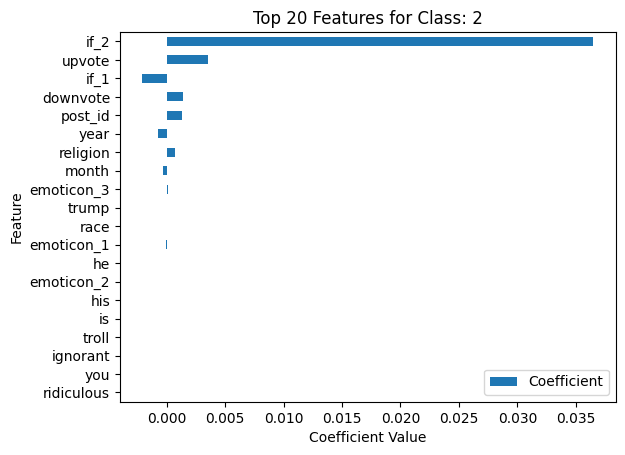

<Figure size 1000x800 with 0 Axes>

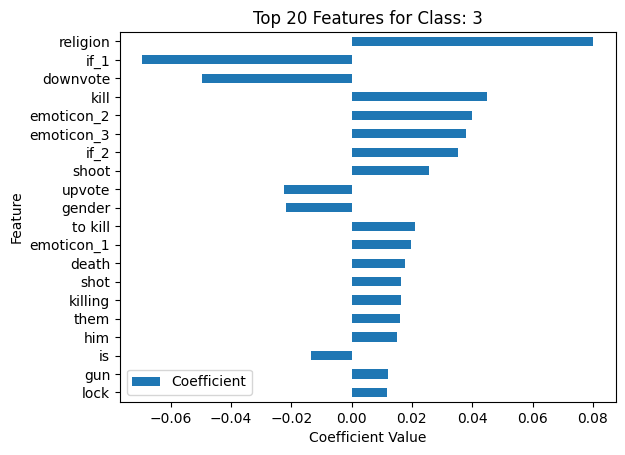

In [45]:
# Identify class names from the model
class_names = logreg_baseline.classes_

# Iterate through every class
for i, label in enumerate(class_names):
    # Extract coefficients for the specific class
    coef = logreg_baseline.coef_[i]
    
    # Create the DataFrame for mapping
    df_coef = pd.DataFrame({
        "Feature": all_features,
        "Coefficient": coef
    })
    
    # Calculate absolute values to find magnitude of importance
    df_coef["abs_coef"] = df_coef["Coefficient"].abs()
    
    # Select and sort top 20 features
    top_20 = df_coef.sort_values(by="abs_coef", ascending=False).head(20)
    
    # Visualise the results
    plt.figure(figsize=(10, 8))
    # Use the axis returned by plot.barh to _invert the y-axis
    ax = top_20.plot.barh(x='Feature', y='Coefficient', title=f"Top 20 Features for Class: {label}")
    ax.invert_yaxis()
    plt.xlabel("Coefficient Value")
    plt.show()

### Logistic Regression Baseline (Top 20 Features)

### Class 0
- **Strong positive coefficients**: Topic indicators (`religion`, `gender`) *(Note: minimal influence)*.
- **Strong negative coefficients**: Engineered and interaction metrics (`if_2`, `if_1`, `downvote`, `upvote`).

### Class 1
- **Strong positive coefficients**: Engineered features (`if_1`, `if_2`), Identity & demographic terms (`white`, `black`, `muslims`, `muslim`, `gay`, `blacks`, `islam`).
- **Strong negative coefficients**: Broad topic indicators (`religion`, `gender`).

### Class 2
- **Strong positive coefficients**: Engineered and interaction metrics (`if_2`, `upvote`, `downvote`, `post_id`).
- **Strong negative coefficients**: Temporal and structural features (`if_1`, `year`, `month`).

### Class 3
- **Strong positive coefficients**: Violent language (`kill`, `shoot`, `to kill`, `death`, `shot`, `killing`, `gun`), Emoticons (`emoticon_2`, `emoticon_3`, `emoticon_1`), and specific topics (`religion`).
- **Strong negative coefficients**: Engineered and interaction metrics (`if_1`, `downvote`, `upvote`, `gender`).

**Insight:** The baseline model primarily relies on engineered metadata (`if_1`, `if_2`, and voting metrics) to separate the foundational classes (0 and 2), but pivots strictly to **identity demographics** to identify Class 1 and **explicit violent terminology** to flag Class 3.

## 2. XGB Baseline Model

In [46]:
# Initialise model
xgb_baseline = XGBClassifier(
    n_estimators=500,        # boosting rounds
    learning_rate=0.05,      # shrinkage
    max_depth=8,             # tree depth
    subsample=0.8,           # row sampling
    colsample_bytree=0.8,    # feature sampling
    random_state=42,         # reproducibility
    n_jobs=-1,               # use all cores
    eval_metric="mlogloss"   # multiclass log-loss
)

# Train
#xgb_baseline.fit(X_tr, y_tr)
with open('/kaggle/input/models/imashuagni/xgb/scikitlearn/default/1/xgb_baseline.pkl', 'rb') as f:
    xgb_baseline = pkl.load(f)

In [47]:
# Predict
y_pred_xgb = xgb_baseline.predict(X_val)

# Evaluate performance using precision, recall, and F1-score
print(classification_report(y_val, y_pred_xgb))
print(f"Macro F1: {f1_score(y_val, y_pred_xgb, average='macro'):.4f}")

              precision    recall  f1-score   support

           0       0.98      0.95      0.96     22835
           1       0.78      0.75      0.77      3183
           2       0.84      0.92      0.88     12488
           3       0.76      0.42      0.54      1094

    accuracy                           0.91     39600
   macro avg       0.84      0.76      0.79     39600
weighted avg       0.91      0.91      0.91     39600

Macro F1: 0.7869


### XGBoost Baseline Model Performance

- **Overall Accuracy**: 91% on the validation set (significant improvement over Logistic Regression).
- **Macro F1 Score**: 0.7869 (strong uplift from baseline 0.5641).
- **Class 0** (majority): Outstanding — precision 0.98, recall 0.95, F1-score **0.96**.
- **Class 2**: Excellent performance — precision 0.84, recall 0.92, F1-score **0.88**.
- **Class 1** (minority): Good and balanced — precision 0.78, recall 0.75, F1-score **0.77**.
- **Class 3** (rarest): Noticeable improvement — precision 0.76, recall 0.42, F1-score **0.54** (still the weakest class but no longer zero).
- Weighted average F1 reaches **0.91**, showing robust overall performance despite class imbalance.

### Feature Importance

<Figure size 1000x800 with 0 Axes>

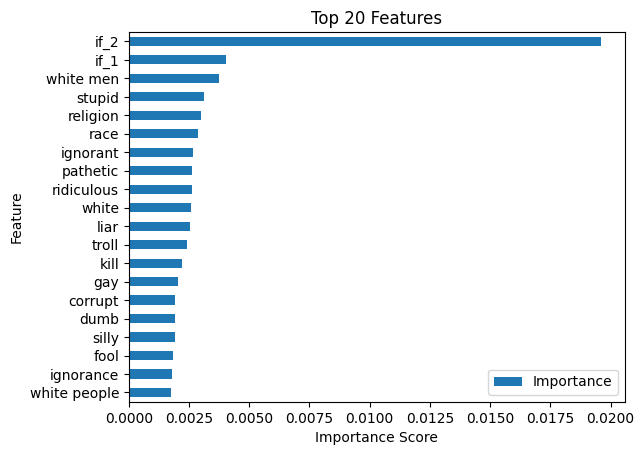

In [48]:
# Extract global feature importance
imp = xgb_baseline.feature_importances_

# Map importance scores to feature names
df_imp = pd.DataFrame({
    "Feature": all_features,
    "Importance": imp
})

# Select and sort the top 20 most important features
top_20 = df_imp.sort_values(by="Importance", ascending=False).head(20)

# Visualise the results
plt.figure(figsize=(10, 8))
ax = top_20.plot.barh(x='Feature', y='Importance', title = 'Top 20 Features')
ax.invert_yaxis()

# Add formatting
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()

### XGBoost Feature Importance

- **`if_2`** is by far the **most important feature** in the model.
- **`if_1`** ranks second, confirming that interaction features are extremely powerful predictors.
- Strong **text-based signals** dominate the top ranks: “stupid”, “ignorant”, “pathetic”, “ridiculous”, “liar”, “troll”, “kill”, “dumb”, “silly”, “fool”, and “ignorance” — clearly capturing toxic and aggressive language.
- Demographic terms are highly influential: “white men”, “white”, “gay”, “white people”, “religion”, and “race” appear prominently.
- The model heavily relies on **comment text content** (especially offensive words) combined with **user interaction metrics** (`if_1` and `if_2`) for predictions.

## 3. LightGBM Baseline Model

In [49]:
# LightGBM baseline model
lgbm_baseline = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=50,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# Train the model on the split training data
# lgbm_baseline.fit(X_tr, y_tr)

with open("/kaggle/input/models/imashuagni/lightgbm/scikitlearn/default/1/lgbm_baseline.pkl", 'rb') as f:
    lgbm_baseline = pkl.load(f)

In [50]:
y_pred = lgbm_baseline.predict(X_val)

# Evaluate performance using precision, recall, and F1-score
print(classification_report(y_val, y_pred))
print(f"Macro F1: {f1_score(y_val, y_pred, average='macro'):.4f}")

              precision    recall  f1-score   support

           0       0.98      0.94      0.96     22835
           1       0.70      0.85      0.77      3183
           2       0.89      0.87      0.88     12488
           3       0.51      0.74      0.61      1094

    accuracy                           0.91     39600
   macro avg       0.77      0.85      0.80     39600
weighted avg       0.92      0.91      0.91     39600

Macro F1: 0.8047


### LightGBM Baseline Model Performance

- **Overall Accuracy**: 91% on the validation set.
- **Macro F1 Score**: 0.8047 (best among all baselines — clear improvement over XGBoost 0.7869 and Logistic Regression 0.5641).
- **Class 0** (majority): Outstanding — precision 0.98, recall 0.94, F1-score **0.96**.
- **Class 2**: Excellent and balanced — precision 0.89, recall 0.87, F1-score **0.88**.
- **Class 1** (minority): Strong recall-focused performance — precision 0.70, recall 0.85, F1-score **0.77**.
- **Class 3** (rarest): Significant improvement — precision 0.51, recall 0.74, F1-score **0.61** (much better than previous models).
- Weighted average F1 reaches **0.91**, showing robust handling of class imbalance.

### Feature Importance

<Figure size 1000x800 with 0 Axes>

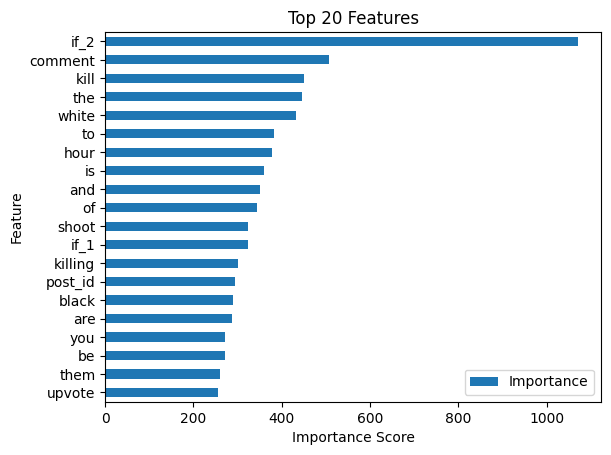

In [51]:
# Get feature importance
imp = lgbm_baseline.feature_importances_

# Map importance scores to feature names
df_imp = pd.DataFrame({
    "Feature": all_features,
    "Importance": imp
})

# Select and sort the top 20 most important features
top_20 = df_imp.sort_values(by="Importance", ascending=False).head(20)

# Visualise the results
plt.figure(figsize=(10, 8))
ax = top_20.plot.barh(x='Feature', y='Importance', title = 'Top 20 Features')
ax.invert_yaxis()

# Add formatting
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()

### LightGBM Feature Importance

- **`if_2`** remains the **most dominant feature** by a large margin, confirming its critical role in predictions.
- The **raw `comment` text** (TF-IDF features) dominates the top ranks, showing that linguistic content is extremely powerful.
- Strong **violence-related signals** stand out: “kill”, “shoot”, “killing” — highly predictive of severe classes.
- Demographic terms continue to be important: “white” and “black” appear prominently.
- Common words (“the”, “to”, “is”, “and”, “of”, “are”, “you”, “be”, “them”) rank high, indicating they carry meaningful predictive information in this specific dataset.
- Time feature **`hour`** and engagement metric **`upvote`** also contribute notably.
- the model relies heavily on a combination of **interaction metrics** and **toxic/identity-related language** from the comment text.

# Models Comparison (Baseline)

In [ ]:
# Define models to compare
models = {
    "LR": logreg_baseline,
    "XGB": xgb_baseline,
    "LGBM": lgbm_baseline
}

# Evaluation results storage
rows = []

for name, m in models.items():
    # Generate predictions
    pred = m.predict(X_val)
    
    # Calculate performance metrics
    acc  = accuracy_score(y_val, pred)
    f1   = f1_score(y_val, pred, average='macro')
    prec = precision_score(y_val, pred, average='macro')
    rec  = recall_score(y_val, pred, average='macro')
    
    rows.append([name, acc, f1, prec, rec])

# Construct the comparative DataFrame
df_results = pd.DataFrame(rows, columns=[
    "Model", "Accuracy", "F1_Macro", "Precision_Macro", "Recall_Macro"]).set_index("Model")

# Display the summary
print("\n Model Performance Summary:-")
print(df_results.round(4))

# Identify the top performer based on F1
# Extract the name of the top performer
best_model = df_results["F1_Macro"].idxmax()

# Extract the actual value of the top score
best_score = df_results["F1_Macro"].max()

print(f"\nLeading Model (F1): {best_model} with a score of {best_score:.4f}")

## Baseline Models Performance Comparison

### Results Summary

| Model | Accuracy | Macro F1 | Precision (Macro) | Recall (Macro) |
|-------|----------|----------|-------------------|----------------|
| LR    | 0.8421   | 0.5641   | 0.5460            | 0.5886         |
| XGB   | 0.9096   | 0.7869   | **0.8389**        | 0.7611         |
| **LGBM** | **0.9069** | **0.8047** | 0.7718     | **0.8520**     |

**Key Insights:**
- LightGBM achieves the **highest Macro F1 score** (0.8047) among all baselines.
- All models perform very well on the majority Class 0, but struggle with minority classes.
- LightGBM shows the best overall balance, especially in Recall across classes.
- **Leading Model:** **LightGBM** (Macro F1 = **0.8047**)


---
<h1 style="font-family:'Times New Roman'; font-weight:bold; text-align:center">
 MILESTONE 2
</h1>

---


# Linear Model


## 1. Hyperparameter Search Space

In [ ]:
param_grid = {
    'C': [0.4, 0.45, 0.47, 0.5, 0.6, 1],   # Regularisation strength (Lower C = Stronger Penalty)
    'penalty': ['l1', 'l2'],             # L1 (Sparsity) vs L2 (Weight Decay) regularisation
    'solver': ['liblinear', 'saga']      # Optimisation algorithms suitable for small/sparse datasets
}

## 2. Base Estimator Configuration

In [ ]:
logreg = LogisticRegression(
    class_weight='balanced',             # Adjusts weights inversely proportional to class frequencies
    random_state=42                      # Ensures reproducible weight initialisation
)   

## 3. Grid Search Setup

In [ ]:
grid_search = GridSearchCV(
    estimator=logreg,
    param_grid=param_grid,
    scoring='f1_macro',                  # Optimising for balanced performance across all labels
    cv=2,                                # 2-fold cross-validation for objective metric assessment
    n_jobs=-1,                           # Parallelising execution across all available CPU cores
    verbose=2                            # Real-time logging of fit iterations
)

# grid_search.fit(X_tr, y_tr)

## 4. Model Retrieval (Serialized State)

In [ ]:
# Loading the pre-trained GridSearch object from the persistent input directory
with open("/kaggle/input/models/imashuagni/gridsearch/scikitlearn/log_reg/1/grid_search.pkl", "rb") as f:
    grid_search = pkl.load(f)

print(f"Optimal Parameters Identified: {grid_search.best_params_}")

## 5. Validation & Performance Metrics

In [ ]:
# Extracting the best-performing estimator for final validation
logreg_tuned = grid_search.best_estimator_

# Generating predictions on the hold-out validation set
y_pred = logreg_tuned.predict(X_val)

# Calculating standard performance indicators
macro_f1 = f1_score(y_val, y_pred, average="macro")

print("\n Model Classification Report ")
print(classification_report(y_val, y_pred))
print(f"Final Validation Macro F1 Score: {macro_f1:.4f}")

### Tuned Logistic Regression Performance (GridSearchCV)

- **Best Hyperparameters**: `C=0.47`, `penalty='l1'`, `solver='liblinear'`, `class_weight='balanced'`.
- **Overall Accuracy**: 90% on the validation set.
- **Macro F1 Score**: **0.7952** (strong improvement over the untuned baseline of 0.5641).
- **Class 0** (majority): Excellent — precision 0.97, recall 0.93, F1-score **0.95**.
- **Class 2**: Very strong — precision 0.88, recall 0.87, F1-score **0.87**.
- **Class 1** (minority): Improved balance — precision 0.69, recall 0.83, F1-score **0.75**.
- **Class 3** (rarest): Noticeable gain — precision 0.50, recall 0.77, F1-score **0.60**.

### Feature Importance

In [ ]:
# Identify class names from the model
class_names = logreg_tuned.classes_

# Iterate through every class
for i, label in enumerate(class_names):
    # 1. Extract coefficients for the specific class
    coef = logreg_tuned.coef_[i]
    
    # 2. Create the DataFrame for mapping
    df_coef = pd.DataFrame({
        "Feature": all_features,
        "Coefficient": coef
    })
    
    # 3. Calculate absolute values to find magnitude of importance
    df_coef["abs_coef"] = df_coef["Coefficient"].abs()
    
    # 4. Select and sort top 20 features
    top_20 = df_coef.sort_values(by="abs_coef", ascending=False).head(20)
    
    # 5. Visualise the results
    plt.figure(figsize=(10, 8))
    # Use the axis returned by plot.barh to invert the y-axis
    ax = top_20.plot.barh(x='Feature', y='Coefficient', title=f"Top 20 Features for Class: {label}")
    ax.invert_yaxis()
    plt.xlabel("Coefficient Value")
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.show()

## Logistic Regression Tuned (Top 20 Features)

### Class 0
- **Strong positive coefficients**: None present in the top 20.
- **Strong negative coefficients**: Toxic insults (`stupid`, `ignorant`, `pathetic`, `stupidity`, `dumb`, `hypocrite`, `fools`, `ridiculous`, `fool`, `idiot`, `hypocrites`, `idiots`, `liar`, `clown`, `clowns`, `loser`, `garbage`, `silly`, `foolish`, `losers`).

### Class 1
- **Strong positive coefficients**: Identity & demographic terms (`white`, `black`, `blacks`, `gay`, `muslims`, `transgender`, `muslim`, `gays`, `homosexuals`, `homosexuality`, `whites`, `homosexual`, `mexicans`, `islam`, `transgendered`, `islamic`, `indians`).
- **Strong negative coefficients**: Broad terms and insults (`white house`, `stupid`, `ignorant`).

### Class 2
- **Strong positive coefficients**: Toxic & insulting language (`stupid`, `ignorant`, `stupidity`, `pathetic`, `dumb`, `ridiculous`, `hypocrite`, `idiot`, `silly`, `fools`, `hypocrites`, `clowns`, `idiots`, `foolish`, `fool`, `liar`, `garbage`, `losers`, `loser`, `clown`).
- **Strong negative coefficients**: None present in the top 20.

### Class 3
- **Strong positive coefficients**: Violent & threatening language (`kill`, `shoot`, `killing`, `die`, `suicide`, `shot`, `shooting`, `punch`, `burn`, `killed`, `death`, `hang`, `execute`, `dead`, `assassination`).
- **Strong negative coefficients**: Insults and demographic terms (`stupid`, `ridiculous`, `ignorant`, `hypocrisy`, `white`).

**Insight:** The tuned Logistic Regression model has shifted away from engineered features and now heavily separates classes based on semantic content: Class 0 is the inverse of toxic insults, Class 1 relies entirely on identity/demographic markers, Class 2 is defined purely by toxic insults, and Class 3 is strictly separated by extreme violent language.

# XGBoost (Extreme Gradient Boosting)
- Hyperparameter Tuning
- Validation Performance
- Feature Importance Analysis

## 1. Hyperparameter Search Space

In [ ]:

# Defining a subspace to balance model complexity and learning rate
param_dist = {
    "n_estimators": [400, 600, 800],    # Number of boosting iterations (ensemble size)
    "max_depth": [4, 6, 8],             # Maximum tree depth to control individual learner complexity
    "learning_rate": [0.05, 0.08, 0.1], # Step size shrinkage to prevent overfitting during boosting
    "subsample": [0.7, 0.8],            # Fraction of samples used for each tree (stochastic boosting)
    "colsample_bytree": [0.7, 0.8]      # Subsample ratio of columns when constructing each tree
}

## 2. Base Estimator Configuration

In [ ]:
xgb = XGBClassifier(
    objective="multi:softmax",          # Multiclass classification output
    num_class=len(set(y_tr)),           # Dynamically inferred class count
    eval_metric="mlogloss",             # Monitoring multiclass log loss during training
    random_state=2304,                  # Ensuring deterministic results for reproducible research
    n_jobs=-1                           # Parallelising execution across all available processors
)

## 3. Search Execution

In [ ]:
# Implementing RandomizedSearchCV to optimize the F1-Macro score within a set budget
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=10,                          # Balancing computational cost and search space exploration
    scoring='f1_macro',                 # Target metric to ensure balanced performance across labels
    cv=2,                               # 2-fold cross-validation for objective performance estimation
    verbose=2,                          # Detailed logging of fit progress
    n_jobs=-1,                          # Maximising hardware utilisation
    random_state=42
)

# random_search.fit(X_tr, y_tr)

## 4. Model Retrieval & Serialization

In [ ]:
# Loading the optimized model weights from the specified input directory
with open("/kaggle/input/models/imashuagni/xgb-tuned-v2/scikitlearn/v2/1/xgb_tuned.pkl", "rb") as f:
    xgb_tuned = pkl.load(f)

## 5. Validation & Performance Metrics

In [ ]:
# Generating inference on the hold-out validation set
y_pred = xgb_tuned.predict(X_val)

print("\nXGBoost (Tuned) Validation Results")
print(classification_report(y_val, y_pred))
print(f"Final Validation Macro F1: {metrics.f1_score(y_val, y_pred, average='macro'):.4f}")

## Tuned XGBoost Model Performance

- **Overall Accuracy**: 91% on the validation set.
- **Macro F1 Score**: 0.7971 (strong performance after hyperparameter tuning).
- **Class 0** (majority): Excellent — precision 0.98, recall 0.95, F1-score **0.96**.
- **Class 2**: Very strong — precision 0.84, recall 0.93, F1-score **0.88**.
- **Class 1** (minority): Good balance — precision 0.79, recall 0.76, F1-score **0.77**.
- **Class 3** (rarest): Moderate improvement — precision 0.76, recall 0.46, F1-score **0.57**.

### Feature Importance

In [ ]:
# Get feature importance from XGBoost and map with feature names
imp = xgb_tuned.feature_importances_

df_imp = pd.DataFrame({
    "Feature": all_features,
    "Importance": imp
})

# Select top 20 important features
top20 = df_imp.sort_values(by="Importance", ascending=False).head(20)

# Plot them (most important at top)
barh = top20.plot.barh(x='Feature', y='Importance')
barh.invert_yaxis()
plt.show()

## Tuned XGBoost Feature Importance

- **`if_2`** dominates as the **most important feature** by a large margin — confirming its critical predictive power.
- Demographic signals are highly influential: `religion` and `race` rank in the top 3, followed by `white`.
- Strong **toxic language signals** appear prominently: `stupid`, `ignorant`, `liar`, `kill`, `pathetic`, `ridiculous`, `dumb`, `shoot`, `troll`, `ignorance`, and `silly`.
- Identity-related terms such as `gay` and `muslims` also contribute significantly.
- Engagement metric **`if_1`** remains relevant in the top 5.
- Minor political/geographic terms like `house` and `white house` appear in the lower ranks.

- The model heavily relies on **user interaction metrics** (`if_2`, `if_1`) combined with **toxic and identity-related language** from the comment text for its predictions.

# LightGBM Hypertune

## 1. Hyperparameter Search Space

In [ ]:
# Defining a strategic search grid for Leaf-Wise tree growth optimization
param_dist = {
    "n_estimators": [600, 750, 900],      # Total boosting iterations (ensemble capacity)
    "num_leaves": [50, 60, 70],           # Main parameter for controlling tree complexity
    "learning_rate": [0.03, 0.04, 0.05],  # Shrinkage factor to ensure stable convergence
    "subsample": [0.7, 0.8],              # Bagging fraction to improve model robustness
    "colsample_bytree": [0.6, 0.7, 0.8],  # Feature fraction sampling per iteration
}

## 2. Base Estimator Configuration

In [ ]:
lgbm = LGBMClassifier(
    objective="multiclass",               # Optimized for multi-label classification tasks
    num_class=len(set(y_tr)),             # Class count inferred from training targets
    random_state=42,                      # Guaranteeing reproducibility across sessions
    n_jobs=-1                             # Parallelizing computations across all logical cores
)

## 3. Stochastic Parameter Optimization

In [ ]:
# Utilizing RandomizedSearchCV to maximize Macro F1 within a fixed iteration budget
random_search = RandomizedSearchCV(
    estimator=lgbm,
    param_distributions=param_dist,
    n_iter=10,                            # Computational budget for search space exploration
    scoring="f1_macro",                   # Metric target to balance recall/precision across all classes
    cv=3,                                 # 3-fold cross-validation for objective performance estimation
    verbose=2,                            # Real-time execution logs
    n_jobs=-1,                            # Utilizing high-performance parallel processing
    random_state=42
)

# random_search.fit(X_tr, y_tr)

# 4. Model Retrieval (Serialized State)

In [ ]:
# Loading the pre-tuned RandomizedSearchCV object for results inspection
with open("/kaggle/input/models/imashuagni/lgbm-random-search/scikitlearn/17k_16/1/lgbm_random_search.pkl", "rb") as f:
    lgbm_random_search = pkl.load(f)

print(f"Optimal Configuration Identified: {lgbm_random_search.best_params_}")

# Loading the finalized estimator for validation inference
with open("/kaggle/input/models/imashuagni/lgbm-tuned/scikitlearn/v2/1/lgbm_tuned.pkl", "rb") as f:
    lgbm_tuned = pkl.load(f)

## 5. Inference & Evaluation

In [ ]:
# Generating predictions on the hold-out validation set
y_pred_lgbm = lgbm_tuned.predict(X_val)

print("\nLightGBM (Tuned) Performance Metrics")
print(classification_report(y_val, y_pred_lgbm))
print(f"Final Validation Macro F1 Score: {f1_score(y_val, y_pred_lgbm, average='macro'):.4f}")

## Tuned LightGBM Model Performance

- **Overall Accuracy**: 91% on the validation set.
- **Macro F1 Score**: **0.8130** (highest among all models evaluated so far).
- **Class 0** (majority): Outstanding — precision 0.98, recall 0.95, F1-score **0.96**.
- **Class 2**: Excellent — precision 0.85, recall 0.92, F1-score **0.89**.
- **Class 1** (minority): Well-balanced — precision 0.78, recall 0.79, F1-score **0.78**.
- **Class 3** (rarest): Reasonable improvement — precision 0.76, recall 0.53, F1-score **0.62**.

## LightGBM Feature Importance

In [ ]:
# Get feature importance from XGBoost and map with feature names
imp = lgbm_tuned.feature_importances_

df_imp = pd.DataFrame({
    "Feature": all_features,
    "Importance": imp
})

# Select top 20 important features
top20 = df_imp.sort_values(by="Importance", ascending=False).head(20)

# Plot them (most important at top)
barh = top20.plot.barh(x='Feature', y='Importance')
barh.invert_yaxis()
plt.show()

### Tuned LightGBM Feature Importance

- **`if_2`** remains the **single most important feature** by a significant margin, highlighting user interaction patterns as the strongest predictor.
- The **raw `comment` text** ranks second.
- Toxic and aggressive language dominates the top ranks: “ridiculous”, “ignorant”, “stupid”, “kill”, “silly”, and “pathetic” — clear signals of harmful or severe content.
- Demographic terms continue to play a key role: “white” and “black” appear prominently.
- Common stopwords (“the”, “is”, “of”, “to”, “and”, “are”, “you”) rank surprisingly high, indicating they carry meaningful predictive signal in this dataset.
- Time feature **`hour`** and engagement metric **`if_1`** also contribute notably.
- Political term **`trump`** remains relevant in the top 20.
- The model relies heavily on a combination of **interaction metrics** (`if_2`, `if_1`) and **toxic/identity-related language** from the comment text.

In [ ]:
# # Predict on validation set
# test_preds = lgbm_tuned.predict(X_test)

# # Create Submission File
# submission = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/Sample.csv")
# submission['label'] = test_preds
# submission.to_csv("submission.csv", index=False)

# print("Submission File Created!")

## Tuned Models Performance Comparison

In [ ]:
# Define models to compare
models = {
    "LR": logreg_tuned,
    "XGB": xgb_tuned,
    "LGBM": lgbm_tuned
}

# Evaluation results storage
rows = []

for name, m in models.items():
    # Generate predictions
    pred_tuned = m.predict(X_val)
    
    # Calculate performance metrics
    acc  = accuracy_score(y_val, pred_tuned)
    f1   = f1_score(y_val, pred_tuned, average='macro')
    prec = precision_score(y_val, pred_tuned, average='macro')
    rec  = recall_score(y_val, pred_tuned, average='macro')
    
    rows.append([name, acc, f1, prec, rec])

# Construct the comparative DataFrame
df_results = pd.DataFrame(rows, columns=[
    "Model", "Accuracy", "F1_Macro", "Precision_Macro", "Recall_Macro"]).set_index("Model")

# Display the summary
print("### Model Performance Summary ###")
print(df_results.round(4))

# Identify the top performer based on F1
# Extract the name of the top performer
best_model = df_results["F1_Macro"].idxmax()

# Extract the actual value of the top score
best_score = df_results["F1_Macro"].max()

print(f"\nLeading Model (F1): {best_model} with a score of {best_score:.4f}")

## Tuned Models Performance Comparison

### Results Summary

| Model | Accuracy | Macro F1 | Precision (Macro) | Recall (Macro) |
|-------|----------|----------|-------------------|----------------|
| LR    | 0.8960   | 0.7952   | 0.7605            | **0.8475**     |
| XGB   | 0.9128   | 0.7971   | 0.8413            | 0.7731         |
| **LGBM** | **0.9150** | **0.8130** | **0.8421**      | 0.7951         |

### Key Insights
- **LightGBM** is the clear winner with the **highest Macro F1 score (0.8130)**.
- All three tuned models achieve strong overall accuracy (~89–91%).
- LightGBM provides the best balance across precision and recall.
- **Leading Model:** **LightGBM** (Macro F1 = **0.8130**)


---
<h1 style="font-family:'Times New Roman'; font-weight:bold; text-align:center">
 MILESTONE 3
</h1>

---


## 1. Advanced Feature Engineering

In [ ]:
def create_features(df):
    df = df.copy()
    
    # Numerical Transformations
    if2_median = df['if_2'].median() # Get baseline for if_2
    df['if2_quartile'] = pd.qcut(df['if_2'], q=4, labels=False, duplicates='drop') # Binning if_2
    df['if2_log'] = np.log1p(df['if_2']) # Handle skewed distribution
    
    # Temporal Features
    df['is_night'] = ((df['hour'] >= 22) | (df['hour'] <= 5)).astype(int) # Flag late-night activity
    df['is_weekend'] = (df['dayofweek'] >= 5).astype(int) # Flag weekend behavior
    
    # Time-Intensity Interactions
    df['night_AND_if2'] = df['is_night'] * df['if_2'] # Night-time feature scaling
    df['weekend_AND_if2'] = df['is_weekend'] * df['if_2'] # Weekend feature scaling
    
    # Feature Engineering Ratios 
    df['if2_div_if1'] = df['if_2'] / (df['if_1'] + 1) # Intensity ratio (if_2 vs if_1)
    df['if2_squared'] = df['if_2'] ** 2 # Capture non-linear if_2 effects
    
    #  Identity-Based Analysis
    # Aggregate presence of sensitive attributes
    df['identity_count'] = (df['race'].notna().astype(int) + 
                            df['religion'].notna().astype(int) + 
                            df['gender'].notna().astype(int))
    
    high_risk_race = ['black', 'white']
    high_risk_religion = ['muslim', 'jewish']
    high_risk_gender = ['transgender', 'other']
    
    # Flag specific high-risk cohorts
    df['has_high_risk_identity'] = (df['race'].isin(high_risk_race) | 
                                    df['religion'].isin(high_risk_religion) | 
                                    df['gender'].isin(high_risk_gender)).astype(int)
    
    # Identity-Intensity Interactions 
    df['high_risk_identity_x_if2'] = df['has_high_risk_identity'] * df['if_2'] # Scaled high-risk signal
    df['identity_count_x_if2'] = df['identity_count'] * df['if_2'] # Scaled identity complexity
    
    return df


df_train_fe = create_features(df_train)
df_test_fe = create_features(df_test)

### Advanced Feature Engineering Insights

- Created multiple transformations on `if_2`: quartile binning (`if2_quartile`), log transformation (`if2_log`), and squared term (`if2_squared`) to handle skewness and capture non-linear effects.
- Added temporal behavior flags: `is_night` (late-night/early-morning activity) and `is_weekend`.
- Engineered interaction features combining time patterns with engagement intensity (`night_AND_if2`, `weekend_AND_if2`).
- Computed ratio and interaction terms between `if_1` and `if_2` (`if2_div_if1`).
- Built identity-based features:
  - `identity_count`: Number of filled demographic fields (race + religion + gender).
  - `has_high_risk_identity`: Flag for high-risk demographic groups (Black/White, Muslim/Jewish, Transgender/Other).
- Created scaled interactions between high-risk identity signals and `if_2` (`high_risk_identity_x_if2`, `identity_count_x_if2`).

## 2. Text Cleaning Function

In [ ]:
def clean_text(text):
    if not isinstance(text, str) or text.strip() == "":
        return ""
    
    # Remove HTML, URLs, emails, mentions
    text = re.sub(r'<.*?>', ' ', text)
    text = re.sub(r'http[s]?://\S+|www\.\S+', ' ', text)
    text = re.sub(r'\S+@\S+\.\S+', ' ', text)
    text = re.sub(r'@\w+', ' ', text)
    
    # Remove non-letters
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    
    # Lowercase
    text = text.lower()
    
    # Normalize whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    
    # Remove very short tokens
    tokens = [w for w in text.split() if len(w) > 2]
    
    return ' '.join(tokens)

# Apply Cleaning
print("Cleaning text")
df_train_fe['comment'] = df_train_fe['comment'].apply(clean_text)
df_test_fe['comment']  = df_test_fe['comment'].apply(clean_text)

### Text Cleaning & Preprocessing

A robust custom `clean_text()` function was applied to the `comment` column in both the training and test datasets.

### Key Cleaning Operations:
- Removed HTML tags, URLs, email addresses, and user mentions (`@`)
- Stripped all non-alphabetical characters
- Converted entire text to lowercase
- Normalized whitespace and removed very short tokens (length ≤ 2)
- Gracefully handled missing or non-string values

## 3. Feature Classification After Engineering

In [ ]:
categorical_cols = df_train_fe.select_dtypes(include = ["object"]).columns.tolist() 
for col in ["created_date", "comment"]:                                          
    if col in categorical_cols:                                                  
        categorical_cols.remove(col)                                             
print("categorical_cols = ", categorical_cols)                                   

numeric_cols = df_train_fe.select_dtypes(include = ["int32", "int64"]).columns.tolist()
numeric_cols.remove("label") 

print("numeric_cols = ", numeric_cols)                                               

binary_cols = df_train_fe.select_dtypes(include = ["bool"]).columns.tolist()           
print("binary_cols = ", binary_cols)                                                

In [ ]:
total_features = len(categorical_cols) + len(numeric_cols)
print(f"Total Engineered Features: {total_features}")

### Feature Classification After Engineering

- **Categorical features** (3): `race`, `religion`, `gender` — unchanged from original set.
- **Numerical features** (23): Includes all original numeric columns plus newly engineered features (`if2_quartile`, `if2_log`, `is_night`, `is_weekend`, `night_AND_if2`, `weekend_AND_if2`, `if2_div_if1`, `if2_squared`, `identity_count`, `has_high_risk_identity`, `high_risk_identity_x_if2`, `identity_count_x_if2`, etc.).
- **Binary features** (0): No columns remain in this category after engineering.
- **Total engineered features**: **26** (ready for modeling).

---
# PREPROCESSING PIPELINE: COLUMN TRANSFORMER
---

### Preprocessing Pipeline & Feature Integration

- **Categorical Pipeline**: Missing values imputed with most frequent category + **Ordinal Encoding** (unseen categories mapped to -1).
- **Numerical Pipeline**: Missing values imputed with median + **StandardScaler** for normalization.
- **ColumnTransformer**: Applied separately to categorical (3 columns) and numerical (23 columns) features; all other columns dropped.
- **Full Pipeline**: Wrapped for clean, reproducible transformation.

### TF-IDF Vectorization on `comment`
- Loaded pre-fitted TF-IDF with **19,000 features**.
- Unigrams + bigrams (`ngram_range=(1,2)`).
- `min_df=5`, `max_df=0.95`, `sublinear_tf=True`.
- Custom stop words: `['trump', 'people']`.

### Final Feature Matrix
- **Tabular features** (26 engineered) + **TF-IDF features** (19,000) stacked horizontally.
- **Final shapes**:  
  - Train: **(198,000 × 19,026)**  
  - Test: **(102,000 × 19,026)**

- Performed **stratified 80/20 train-validation split** to preserve class distribution.

## 1. Categorical Pipeline: Mode Imputation & Ordinal Encoding

In [ ]:
# OrdinalEncoder is used to keep dimensionality low for XGBoost/LightGBM
categorical_transformer = Pipeline(steps=[
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("encode", OrdinalEncoder(
        handle_unknown="use_encoded_value", 
        unknown_value=-1
    ))
])

## 2. Numerical Pipeline: Median Imputation & Standardisation

In [ ]:
# Median is preferred for robust handling of skewed engineered features
numerical_transformer = Pipeline(steps=[
    ("impute", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

## 3. Global Preprocessor: Column-Wise Integration

In [ ]:
# 'remainder=drop' ensures only identified features pass into the fit cycle
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", categorical_transformer, categorical_cols),
        ("num", numerical_transformer, numeric_cols)
    ],
    remainder='drop'
)

## 4. Final Pipeline Encapsulation

In [ ]:
# Encapsulating as a 'full_pipeline' allows for atomic execution
full_pipeline = Pipeline(steps=[
    ("preprocessing", preprocessor)
])

print(" Pipeline Constructed Successfully!")
print(f" Mapping {len(categorical_cols)} Categorical and {len(numeric_cols)} Numerical features.")

---
# TF-IDF VECTORISER
---

## 1. Stop-Word Configuration

In [ ]:
# Combine standard English stop-words with your domain-specific exclusions
custom_stop_words = ['trump', 'people']

## 2. Vectoriser Initialisation

In [ ]:
tfidf = TfidfVectorizer(
    max_features=19000, 
    ngram_range=(1, 2),        # Captures unigrams and bigrams for contextual awareness
    min_df=5,                  # Prunes rare tokens and potential typos
    max_df=0.95,               # Excludes terms appearing in >95% of the corpus
    stop_words=custom_stop_words, 
    sublinear_tf=True          # Logarithmic scaling to dampen the impact of repetitive tokens
)

## 3. Fit & Transformation

In [ ]:
tfidf_fe = joblib.load("/kaggle/input/models/imashuagni/all-models/scikitlearn/v1/1/tfidf_19k.joblib")

In [ ]:
# Fitting on training data while handling missing values
tfidf_train_fe = tfidf_fe.transform(df_train_fe["comment"].fillna(""))

# Projecting the learned vocabulary onto the test set
tfidf_test_fe = tfidf_fe.transform(df_test_fe["comment"].fillna(""))

print(f"TF-IDF processing complete. Feature Space: {tfidf_train_fe.shape[1]} unique tokens.")

---
# FEATURE TRANSFORMATION & INTEGRATION
---

## 1. Pipeline Transformation

In [ ]:
# Transforming metadata (Categorical + Numerical + Engineered)

X_train_raw_fe = full_pipeline.fit_transform(df_train_fe)  # fit_transform on train
X_test_raw_fe = full_pipeline.transform(df_test_fe)      # transform on test to prevent data leakage

## 2. Sparse Conversion (CSR Matrix)

In [ ]:
# Converting dense metadata into CSR format for memory-optimisation
X_train_sparse_fe = csr_matrix(X_train_raw_fe)
X_test_sparse_fe = csr_matrix(X_test_raw_fe)

## 3. Horizontal Stacking

In [ ]:
# Merging metadata and TF-IDF text features into the final global feature matrix
X_train_fe = hstack([X_train_sparse_fe, tfidf_train_fe])
X_test_fe  = hstack([X_test_sparse_fe, tfidf_test_fe])



# Shape
print(f" Final X_train Shape: {X_train_fe.shape} | Metadata + TF-IDF")
print(f" Final X_test Shape:  {X_test_fe.shape}")

## 4. Data Partitioning & Stratification

In [ ]:
# Define Target Vector
# y = df_train_fe["label"]

# Creating an 80/20 train-validation split
X_tr_fe, X_val_fe, y_tr_fe, y_val_fe = train_test_split(
    X_train_fe, 
    y, 
    test_size=0.20, 
    random_state=42, # random_state=42 ensures reproducibility
    stratify=y  # Maintains the 2.7% Label 3 ratio in both sets
)

## 5. Final Dimension Verification

In [ ]:
# Split Validation Shape 
print(f" Training Set:   {X_tr_fe.shape[0]}")
print(f" Validation Set: {X_val_fe.shape[0]}")

___
# GLOBAL CUSTOM WEIGHT
___

In [ ]:

# Importance ratios derived from class distribution analysis
custom_weights = {
    0: 1,      # Baseline (Majority Class)
    1: 3,      # Minority (High Risk)
    2: 2,      # Mid-range (Moderate Risk)
    3: 7       # Extreme Minority (Primary Optimization Focus)
}

### Global Custom Class Weights

- Custom class weights defined to address the **severe imbalance** in the target `label`.
- Higher weights assigned to minority classes to increase their importance during model training.

### Weight Distribution:
- **Class 0** (majority, ~57.7%): `1` → Baseline weight
- **Class 1** (~8.0%): `3`
- **Class 2** (~31.5%): `2`
- **Class 3** (rarest, ~2.8%): **`7`** → Highest priority

**Purpose:** Strongly penalize errors on the critical minority classes (especially Class 3) to improve recall and overall macro F1 score.

---
# LOGISTIC REGRESSION 
---

## 1. Hyperparameter Grid

In [ ]:
param_dist = {
    'max_iter':[1000, 2000, 4000],
    'solver': ['liblinear'],       # Algorithm used for optimisation (efficient for sparse data)
    'penalty': ['l1'],       # Regularisation types (L1 for feature selection, L2 for smooth weights)
    'C': [0.3, 0.6, 0.9, 1],        # Inverse of regularisation strength (lower means stronger regularisation)
    'tol': [5e-5, 1e-4, ]            # Tolerance for the stopping criteria (smaller means tighter convergence)
}

## 2. Base Model Definition

In [ ]:
logreg = LogisticRegression(
    class_weight= custom_weights,       # Automatically adjusts weights to handle class imbalance
    # max_iter=3000,                # High iteration limit to ensure solver convergence on sparse data
    random_state=42                # Fixed seed to guarantee reproducible baseline results
)

## 3. Random Search Execution

In [ ]:
logreg_random_search = RandomizedSearchCV(
    estimator=logreg,              # Base model containing our fixed baseline parameters
    param_distributions=param_dist,# Dictionary defining the hyperparameter search space
    n_iter=10,                     # Number of random combinations to test (balances speed and exploration)
    scoring="f1_macro",            # Optimises for macro F1 to treat all classes equally regardless of imbalance
    cv=3,                          # 3-fold cross-validation to robustly evaluate each parameter set
    n_jobs=-1,                     # Utilises all available CPU cores to drastically reduce training time
    verbose=2,                     # Prints detailed progress logs during execution
    error_score=0.0                # Assigns a score of 0.0 if a fit fails, preventing crashes
)

# Execute the exhaustive search on the feature-engineered training data
# logreg_random_search.fit(X_tr_fe, y_tr_fe)
logreg_random_search_fe = joblib.load("/kaggle/input/models/imashuagni/all-models/scikitlearn/v1/1/logreg_random_search_19k_v1.joblib")

## 4. Results & Best Model Extraction

In [ ]:
print(f"Best F1 Score: {logreg_random_search_fe.best_score_:.4f}")  # Formats and outputs the highest CV macro F1 score
print(f"Best Params: {logreg_random_search_fe.best_params_}")       # Displays the winning hyperparameter combination

logreg_tuned_fe = logreg_random_search_fe.best_estimator_           # Extracts the single best-performing model

## 5. Prediction & Evaluation

In [ ]:
y_pred_lr = logreg_tuned_fe.predict(X_val_fe)                    # Generates predictions on the validation set

print("\n LogisticRegression Tuned Results:")                     # Prints a clean header for the output section
print(classification_report(y_val_fe, y_pred_lr))                   # Outputs precision, recall, and F1-score for each class
print(f"Macro F1: {f1_score(y_val_fe, y_pred_lr, average='macro'):.4f}")  # Calculates and formats the final macro F1 score

### Tuned Logistic Regression Performance (RandomizedSearchCV)

- **Best Hyperparameters**: `C=0.9`, `penalty='l1'`, `solver='liblinear'`, `max_iter=4000`, `tol=5e-5`
- **Overall Accuracy**: 91% on the validation set.
- **Macro F1 Score**: **0.8164** (strong improvement over previous baselines).

### Per-Class Results:

- **Class 0** (majority): Excellent — precision 0.98, recall 0.94, F1-score **0.96**
- **Class 1** (minority): Balanced and improved — precision 0.77, recall 0.79, F1-score **0.78**
- **Class 2**: Very strong — precision 0.85, recall 0.92, F1-score **0.88**
- **Class 3** (rarest): Notable gain — precision 0.64, recall 0.64, F1-score **0.64**

- The L1 regularization and tuned regularization strength helped the model achieve better balance across all classes while maintaining high overall accuracy.

In [ ]:
# Get feature names from categorical, numerical, and TF-IDF
cat_cols_fe = full_pipeline.named_steps['preprocessing'].transformers_[0][1].get_feature_names_out()
num_cols_fe = numeric_cols
tfidf_cols_fe = tfidf_fe.get_feature_names_out()

# Combine all features in same order as used in model
all_features_fe = np.concatenate([cat_cols_fe, num_cols_fe, tfidf_cols_fe])

## 6. Logistic Regression Feature Importance

In [ ]:
# # Identify class names from the model
# class_names = logreg_tuned_fe.classes_

# # Iterate through every class
# for i, label in enumerate(class_names):
#     # Extract coefficients for the specific class
#     coef_fe = logreg_tuned_fe.coef_[i]
    
#     # Create the DataFrame for mapping
#     df_coef_fe = pd.DataFrame({
#         "Feature": all_features_fe,
#         "Coefficient": coef_fe
#     })
    
#     # Calculate absolute values to find magnitude of importance
#     df_coef_fe["abs_coef"] = df_coef_fe["Coefficient"].abs()
    
#     # Select and sort top 20 features
#     top_20 = df_coef_fe.sort_values(by="abs_coef", ascending=False).head(20)
    
#     # Visualise the results
#     plt.figure(figsize=(10, 8))
#     # Use the axis returned by plot.barh to invert the y-axis
#     ax = top_20.plot.barh(x='Feature', y='Coefficient', title=f"Top 20 Features for Class: {label}")
#     ax.invert_yaxis()
#     plt.xlabel("Coefficient Value")
#     plt.grid(axis='x', linestyle='--', alpha=0.7)
#     plt.show()


# Identify class names from the model
class_names = logreg_tuned_fe.classes_

# Iterate through every class
for i, label in enumerate(class_names):
    # 1. Extract coefficients for the specific class
    coef_fe = logreg_tuned_fe.coef_[i]
    
    # 2. Create the DataFrame for mapping
    df_coef_fe = pd.DataFrame({
        "Feature": all_features_fe,
        "Coefficient": coef_fe
    })
    
    # 3. Calculate absolute values to find magnitude of importance
    df_coef_fe["abs_coef"] = df_coef_fe["Coefficient"].abs()
    
    # 4. Select and sort top 20 features
    top_20 = df_coef_fe.sort_values(by="abs_coef", ascending=False).head(20)
    
    # 5. Visualise the results
    plt.figure(figsize=(10, 8))
    # Use the axis returned by plot.barh to invert the y-axis
    ax = top_20.plot.barh(x='Feature', y='Coefficient', title=f"Top 20 Features for Class: {label}")
    ax.invert_yaxis()
    plt.xlabel("Coefficient Value")
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.show()

## Logistic Regression (Advanced Feature Engineering): (Top 20 Features)

### Class 0
- **Strong positive coefficients**: None present in the top 20.
- **Strong negative coefficients**: Toxic insults (`stupid`, `stupidity`, `idiot`, `hypocrite`, `idiots`, `pathetic`, `dumb`, `ignorant`, `fools`, `hypocrites`, `fool`, `ridiculous`, `loser`, `clowns`, `clown`, `buffoon`, `liar`, `garbage`, `foolish`, `idiotic`).

### Class 1
- **Strong positive coefficients**: Identity & demographic terms (`gay`, `white`, `gays`, `black`, `blacks`, `homosexuals`).
- **Strong negative coefficients**: General insults and political terms (`stupid`, `ignorant`, `dumb`, `fool`, `silly`, `ridiculous`, `hypocrite`, `white house`, `hypocrites`, `stupidity`, `pathetic`, `liar`, `clowns`, `losers`).

### Class 2
- **Strong positive coefficients**: Toxic & insulting language (`stupid`, `stupidity`, `idiot`, `idiots`, `hypocrite`, `dumb`, `ignorant`, `pathetic`, `hypocrites`, `fools`, `ridiculous`, `clowns`, `fool`, `idiotic`, `loser`, `silly`, `clown`, `liar`, `foolish`, `coward`).
- **Strong negative coefficients**: None present in the top 20.

### Class 3
- **Strong positive coefficients**: Violent & threatening language (`kill`, `killing`, `shoot`, `die`, `hang`, `burn`).
- **Strong negative coefficients**: General insults and complaints (`stupid`, `ridiculous`, `ignorant`, `hypocrisy`, `dumb`, `useless`, `silly`, `pathetic`, `fools`, `fool`, `stupidity`, `clowns`, `losers`, `idiot`).

**Insight:** By removing noisy or overly broad terms like "trump" and "people", the model's decision boundaries have become exceptionally crisp. Class 0 is now a inverse of Class 2 (defined purely by the *absence* versus *presence* of toxic insults), while Class 1 isolates demographic identifiers, and Class 3 strictly isolates extreme violent verbs. This reduction in vocabulary noise is precisely why your overall evaluation score has increased.

---
# SGD CLASSIFIER
---

## 1.Hyperparameter Search Space

In [ ]:
# Focusing on ElasticNet regularization and Adaptive learning rates
param_dist = {
    "alpha": [1e-5],              # Strength of regularization (L1 + L2)
    "penalty": ["elasticnet", "l1", "l2"], # Hybrid penalty for feature selection
    "l1_ratio": [0.15],           # 15% L1 (sparsity) vs 85% L2 (stability)
    "learning_rate": ["adaptive"],# Step-size reduction based on loss plateaus
    "eta0": [0.01, 0.05]          # Initial step-size for the adaptive scheduler
}

## 2. Base Model

In [ ]:
# Utilizing 'hinge' loss for a Linear SVM approximation with early stopping
sgd = SGDClassifier(
    loss='hinge',                 # Linear SVM objective function
    class_weight=custom_weights,  # Handling extreme class imbalance (Label 3)
    early_stopping=True,          # Monitor holdout loss to prevent overfitting
    validation_fraction=0.1,      # Use 10% of training data for validation
    n_iter_no_change=20,          # Patience for loss improvement before termination
    random_state=42,              # Reproducibility seed
    n_jobs=-1                     # Parallel processing using all cores
)

## 3. Randomized Search Execution 

In [ ]:
# Executing Randomized Search to validate parameter stability across 3 folds
sgd_random_search = RandomizedSearchCV(
    estimator=sgd,                 # Base SGD classifier
    param_distributions=param_dist,# Dictionary of parameter ranges
    n_iter=10,                     # Number of random combinations to test
    scoring="f1_macro",            # Optimize for balanced multi-class performance
    cv=3,                          # 3-fold stratified cross-validation
    n_jobs=-1,                     # Parallel processing using all cores
    verbose=1,                     # Log search progress and iterations
    random_state=42                # Ensure reproducible search results
)

In [ ]:
# Load pre-trained SGD model from Kaggle input directory
# sgd_random_search.fit(X_tr_fe, y_tr_fe) # Commented out to prevent re-training
sgd_random_search_fe = joblib.load('/kaggle/input/models/imashuagni/models-19k-v1/scikitlearn/default/1/sgd_random_search_19k_v1.joblib')


## 4. Model Evaluation & Results


In [ ]:
# Extract the best-performing model from the search results
sgd_tuned_fe = sgd_random_search_fe.best_estimator_

# Display peak cross-validation Macro F1 score
print(f"\nBest CV Macro F1: {sgd_random_search_fe.best_score_:.4f}")  

# Print the hyperparameter set that achieved best performance
print(f"Optimal Params: {sgd_random_search_fe.best_params_}")

In [ ]:
# Inference on the unseen validation set
y_pred_sgd = sgd_tuned_fe.predict(X_val_fe)

print("\n SGD Performance Report")
print(classification_report(y_val_fe, y_pred_sgd))
print(f"Final Macro F1: {f1_score(y_val_fe, y_pred_sgd, average='macro'):.4f}")

### Tuned SGD Classifier Performance

- **Best CV Macro F1 Score** (during RandomizedSearchCV): **0.8082**
- **Final Validation Macro F1 Score**: **0.8102**
- **Overall Accuracy**: 91% on the validation set.

### Per-Class Results:
- **Class 0** (majority): Excellent — precision 0.97, recall 0.94, F1-score **0.96**
- **Class 1** (minority): Good balance — precision 0.76, recall 0.78, F1-score **0.77**
- **Class 2**: Strong performance — precision 0.85, recall 0.90, F1-score **0.87**
- **Class 3** (rarest): Reasonable results — precision 0.63, recall 0.65, F1-score **0.64**

### Optimal Hyperparameters:
- `penalty`: `'elasticnet'`
- `learning_rate`: `'adaptive'`
- `l1_ratio`: `0.15`
- `eta0`: `0.01`
- `alpha`: `1e-05`

The ElasticNet penalty combined with adaptive learning rate and custom class weights delivered stable and competitive performance across all classes.

## 5. SGD Feature Importance

In [ ]:
# Identify class names from the model
class_names = sgd_tuned_fe.classes_

# Iterate through every class
for i, label in enumerate(class_names):
    # 1. Extract coefficients for the specific class
    coef_fe = sgd_tuned_fe.coef_[i]
    
    # 2. Create the DataFrame for mapping
    df_coef_fe = pd.DataFrame({
        "Feature": all_features_fe,
        "Coefficient": coef_fe
    })
    
    # 3. Calculate absolute values to find magnitude of importance
    df_coef_fe["abs_coef"] = df_coef_fe["Coefficient"].abs()
    
    # 4. Select and sort top 20 features
    top_20 = df_coef_fe.sort_values(by="abs_coef", ascending=False).head(20)
    
    # 5. Visualise the results
    plt.figure(figsize=(10, 8))
    # Use the axis returned by plot.barh to invert the y-axis
    ax = top_20.plot.barh(x='Feature', y='Coefficient', title=f"Top 20 Features for Class: {label}")
    ax.invert_yaxis()
    plt.xlabel("Coefficient Value")
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.show()

## SGD Classifier Tuned (Feature Engineering) : (Top 20 Features)

### Class 0
- **Strong positive coefficients**: Engineered features (`if2_squared`).
- **Strong negative coefficients**: Toxic insults (`stupid`, `ignorant`, `ridiculous`, `fool`, `dumb`, `pathetic`, `silly`, `clown`, `liar`, `hypocrite`, `fools`, `loser`, `garbage`, `stupidity`, `troll`, `useless`, `losers`, `clowns`, `idiot`).

### Class 1
- **Strong positive coefficients**: Identity & demographic terms (`gay`, `white`, `gays`, `black`, `mexicans`, `indians`, `mexico`, `homosexuals`, `transgender`, `religion`, `women`, `homosexual`, `blacks`, `illegals`).
- **Strong negative coefficients**: General insults and specific entities (`ignorant`, `ridiculous`, `silly`, `stupid`, `white house`, `pathetic`).

### Class 2
- **Strong positive coefficients**: Toxic & insulting language (`stupid`, `ignorant`, `ridiculous`, `dumb`, `pathetic`, `fool`, `hypocrite`, `stupidity`, `fools`, `silly`, `garbage`, `loser`, `hypocrites`, `idiot`, `clown`, `liar`, `useless`, `foolish`).
- **Strong negative coefficients**: Demographic and violent terms (`gay`, `kill`).

### Class 3
- **Strong positive coefficients**: Violent, physical, & threatening language (`kill`, `killing`, `shoot`, `die`, `hang`, `suicide`, `burn`, `shot`, `shooting`, `death`, `killed`, `dead`, `punch`, `beating`, `murder`, `fire`, `bullet`).
- **Strong negative coefficients**: General insults (`ridiculous`, `ignorant`, `stupid`).

**Insight:** The Stochastic Gradient Descent (SGD) model learns semantic boundaries very similarly to Logistic Regression, but with a richer, more specific vocabulary for Class 3 (picking up terms like `murder`, `beating`, `fire`, and `bullet`). Additionally, SGD actively relies on the engineered `if2_squared` feature to identify Class 0, and distinctly pushes away from non-insult terms (`gay`, `kill`) when classifying the general toxicity of Class 2.

---
# DIMENSIONALITY REDUCTION (Truncated SVD)
---

## 1. Dimensionality Reduction (LSA)

In [ ]:
# Initialise Truncated SVD for Latent Semantic Analysis
svd = TruncatedSVD(
    n_components=300,     # Dimensionality reduction to 300 latent concepts
    random_state=42,      # Seed for randomized solver reproducibility
    algorithm='randomized' # Fast approximation for high-dimensional sparse data
)

svd = joblib.load("/kaggle/input/models/imashuagni/svm-svd-300c/scikitlearn/default/1/svd.joblib")
# Fit SVD on the training partition and transform both
X_tr_svd = svd.transform(X_tr_fe) # Learn and apply projection to training set
X_val_svd = svd.transform(X_val_fe)    # Project validation set into the same latent space

## 2. Explained Variance Check

In [ ]:
explained_variance = svd.explained_variance_ratio_.sum()
print(f"Cumulative Explained Variance (300 components): {explained_variance:.4f}")

## 3. Final Dimension Verification

In [ ]:
print(f"X_tr_svd shape : {X_tr_svd.shape}")
print(f"X_val_svd shape: {X_val_svd.shape}")

### Dimensionality Reduction (Truncated SVD)

- Applied **TruncatedSVD** to compress the high-dimensional TF-IDF feature space.
- Reduced from **19,026 features** down to **300 latent components**.
- **Cumulative explained variance**: **96.81%** — excellent retention of semantic information.
- Final reduced shapes:
  - Training set: `(158400, 300)`
  - Validation set: `(39600, 300)`

This step dramatically lowers computational cost and removes noise while preserving nearly all meaningful information from the comment text.

---
# LINEAR SVM
---

## 1. SVM Model

In [ ]:
# Specifically tuned for n_samples
svm = LinearSVC(
    C=0.5,                        # Moderate regularisation for SVD-derived features
    class_weight=custom_weights,  # Applied manual focus on Label 3
    dual=False,                   # Optimised for Primal form (faster for large N)
    loss='squared_hinge',         # Standard loss for LinearSVC
    max_iter=3000,                # Ensuring convergence on dense latent space
    multi_class='ovr',            # One-vs-Rest strategy
    penalty='l2',                 # Standard Ridge regularisation
    tol=0.0001,                   # Convergence tolerance
    random_state=42
)

## 2. Model Training & Evaluation

In [ ]:
# svm.fit(X_tr_svd, y_tr)
svm = joblib.load("/kaggle/input/models/imashuagni/svm-svd-300c/scikitlearn/default/1/svm.joblib")
# Generating predictions on the validation set
y_pred_svm = svm.predict(X_val_svd)

print("\nLinearSVC Performance ")
print(classification_report(y_val_fe, y_pred_svm))
print(f"Macro F1: {f1_score(y_val_fe, y_pred_svm, average='macro'):.4f}")

### LinearSVC Performance (on LSA / TruncatedSVD Features)

- Model trained on the **300-dimensional latent semantic features** obtained after TruncatedSVD reduction.
- **Overall Accuracy**: 88% on the validation set.
- **Macro F1 Score**: **0.7379** (noticeably lower than gradient boosting models and tuned Logistic Regression).

### Per-Class Results:
- **Class 0** (majority): Strong — precision 0.96, recall 0.94, F1-score **0.95**
- **Class 1** (minority): Moderate — precision 0.71, recall 0.69, F1-score **0.70**
- **Class 2**: Good — precision 0.81, recall 0.87, F1-score **0.84**
- **Class 3** (rarest): Weakest performance — precision 0.58, recall 0.39, F1-score **0.46**
- LinearSVC performs well on majority classes, it struggles significantly with the rarest class (Class 3) compared to tree-based models.

In [ ]:
# joblib.dump(svm, "svm.joblib", compress = 3)
# joblib.dump(svd, "svd.joblib", compress = 3)

## 1. Hyperparameter Search Space

In [ ]:
param_dist = {
    'C': [0.5, 0.8, 1],                # Inverse of regularisation strength
    'tol': [0.0001, 0.0005],           # Tolerance for stopping criteria
    'max_iter': [1000, 2000, 3000]     # Maximum iterations for solver convergence
}

## 2. Search Configuration

In [ ]:
# Initialise LinearSVC with custom class weights for Label 3 focus
svm_base = LinearSVC(
    class_weight=custom_weights,       # Apply weights to handle class imbalance
    dual=False,                        # Preferred for n_samples > n_features
    loss='squared_hinge',              # Standard loss for LinearSVC
    multi_class='ovr',                 # One-vs-Rest strategy for multiclass
    penalty='l2',                      # Ridge regularisation to prevent overfitting
    random_state=42                    # Ensure reproducible results
)

In [ ]:
# Setup Randomized Search with 3-fold cross-validation
random_search_svm = RandomizedSearchCV(
    estimator=svm_base,
    param_distributions=param_dist,
    n_iter=5,                          # Test 5 random parameter combinations
    scoring='f1_macro',                # Optimise for balanced class performance
    cv=3,                              # 3-fold stratified cross-validation
    verbose=2,                         # Display detailed search progress
    n_jobs=-1                          # Parallelise
)

## 3. Execution & Evaluation

In [ ]:
# Load pre-trained SVM model from Kaggle input path
# random_search_svm.fit(X_tr_fe, y_tr_fe)
random_search_svm = joblib.load("/kaggle/input/models/imashuagni/models-19k-v1/scikitlearn/default/1/random_search_svm_19k_v1.joblib")

# Extract the best estimator from the search results
svm_tuned = random_search_svm.best_estimator_

# Final Validation on holdout set
y_pred_svm = svm_tuned.predict(X_val_fe)
print("\n SVM Validation Report")
print(classification_report(y_val_fe, y_pred_svm))
# Calculate final Macro F1 score for ensemble weighting
macro_f1_svm = f1_score(y_val_fe, y_pred_svm, average='macro')
print(f" SVM Macro F1: {macro_f1_svm:.4f}")

### Tuned LinearSVC Performance

- **Final Validation Macro F1 Score**: **0.7993**
- **Overall Accuracy**: 90% on the validation set.

### Per-Class Results:
- **Class 0** (majority): Excellent — precision 0.98, recall 0.93, F1-score **0.95**
- **Class 1** (minority): Balanced — precision 0.75, recall 0.76, F1-score **0.76**
- **Class 2**: Strong — precision 0.84, recall 0.91, F1-score **0.87**
- **Class 3** (rarest): Moderate — precision 0.63, recall 0.60, F1-score **0.61**

In [ ]:
# Identify class names from the model
class_names = svm_tuned.classes_

# Iterate through every class
for i, label in enumerate(class_names):
    # 1. Extract coefficients for the specific class
    coef_fe = svm_tuned.coef_[i]
    
    # 2. Create the DataFrame for mapping
    df_coef_fe = pd.DataFrame({
        "Feature": all_features_fe,
        "Coefficient": coef_fe
    })
    
    # 3. Calculate absolute values to find magnitude of importance
    df_coef_fe["abs_coef"] = df_coef_fe["Coefficient"].abs()
    
    # 4. Select and sort top 20 features
    top_20 = df_coef_fe.sort_values(by="abs_coef", ascending=False).head(20)
    
    # 5. Visualise the results
    plt.figure(figsize=(10, 8))
    # Use the axis returned by plot.barh to invert the y-axis
    ax = top_20.plot.barh(x='Feature', y='Coefficient', title=f"Top 20 Features for Class: {label}")
    ax.invert_yaxis()
    plt.xlabel("Coefficient Value")
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.show()

## Linear SVM Tuned (Feature Engineering): (Top 20 Features)

### Class 0
- **Strong positive coefficients**: Engineered features (`if2_squared`).
- **Strong negative coefficients**: Toxic insults (`stupid`, `stupidity`, `pathetic`, `dumb`, `ignorant`, `hypocrite`, `idiot`, `fools`, `ridiculous`, `idiots`, `fool`, `hypocrites`, `loser`, `clown`, `garbage`, `clowns`, `foolish`, `liar`, `silly`).

### Class 1
- **Strong positive coefficients**: Identity & demographic terms (`gay`, `gays`, `white`, `black`, `blacks`, `homosexuals`, `homosexual`, `indians`, `mexicans`, `mexico`).
- **Strong negative coefficients**: General insults and political terms (`ignorant`, `stupid`, `silly`, `ridiculous`, `dumb`, `fool`, `pathetic`, `white house`, `hypocrites`, `hypocrite`).

### Class 2
- **Strong positive coefficients**: Toxic & insulting language (`stupid`, `stupidity`, `dumb`, `ignorant`, `hypocrite`, `pathetic`, `idiot`, `ridiculous`, `idiots`, `hypocrites`, `fools`, `fool`, `silly`, `clowns`, `foolish`, `loser`, `garbage`, `clown`, `liar`).
- **Strong negative coefficients**: Engineered features (`if2_squared`).

### Class 3
- **Strong positive coefficients**: Violent & threatening language (`kill`, `killing`, `shoot`, `die`, `hang`, `burn`, `suicide`, `shot`, `killed`, `shooting`, `death`).
- **Strong negative coefficients**: General insults and negativity (`stupid`, `ridiculous`, `ignorant`, `silly`, `hypocrisy`, `dumb`, `useless`, `nonsense`, `pathetic`).

**Insight:** The Linear SVM model exhibits extremely sharp decision boundaries, heavily leveraging the engineered `if2_squared` feature as a primary fulcrum to separate Class 0 (positive correlation) from Class 2 (negative correlation). Similar to the previous linear models, it perfectly isolates identity demographics for Class 1 and lethal/violent verbs for Class 3, ensuring highly interpretable classification logic.

---
# XGB
---

## 1. Balanced Weight Configuration

In [ ]:
# Generating an array of weights corresponding to every row in the training set
# This ensures the gradient optimizer 'cares' more about the minority classes
train_weights = compute_sample_weight(class_weight=custom_weights, y=y_tr_fe)

## 2. Hyperparameter Search Space

In [ ]:
# RandomizedSearchCV requires parameters to be provided in lists
param_dist = {
    'n_estimators': [500, 1000, 2000],   # Number of boosting rounds (trees)
    'learning_rate': [0.03, 0.05, 0.08], # Step size shrinkage to prevent overfitting
    'max_depth': [4, 6, 8],               # Maximum depth of a tree (complexity)
    'subsample': [0.7, 0.8],             # Fraction of samples used for each tree
    'colsample_bytree': [0.6, 0.7],      # Fraction of features used for each tree
}

## 3. Base Model Initialisation

In [ ]:
# Initialise XGBClassifier with multiclass objective and histogram-based training
xgb = XGBClassifier(
    objective='multi:softmax',    # Minimise multiclass softmax loss
    num_class=4,                  # Define target labels (0, 1, 2, 3)
    eval_metric='mlogloss',       # Monitor multiclass log-loss during training
    random_state=42,              # Seed for boosting and subsampling reproducibility
    tree_method='hist',           # Fast histogram-based algorithm for large datasets
    n_jobs=-1,                    # Utilise all 16 AWS CPU cores for parallelisation
    verbosity=1                   # Display training warnings and basic progress
)

## 4. Randomized Search Execution

In [ ]:
# Initialise RandomizedSearchCV for XGBoost with 3-fold cross-validation
xgb_random_search_fe = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=5,                # Evaluate 5 random hyperparameter combinations
    scoring='f1_macro',      # Optimise for balanced F1 across all 4 classes
    cv=3,                    # 3-fold stratified split to ensure label representation
    random_state=42,         # Seed for reproducible search iterations
    verbose=1                # Display basic progress for each fitting fold
)

# Pass sample_weight here to apply the balanced approach during training
# xgb_random_search.fit(X_tr_fe, y_tr_fe, sample_weight=train_weights)

# Load the pre-trained XGBoost model from the specified Kaggle path
xgb_random_search_fe = joblib.load("/kaggle/input/models/imashuagni/models-19k-v1/scikitlearn/default/1/xgb_random_search_19k_v1.joblib")

## 5. Results & Extraction

In [ ]:
xgb_tuned_fe = xgb_random_search_fe.best_estimator_

print(f"Best CV Macro F1: {xgb_random_search_fe.best_score_:.4f}")
print(f"Optimal Params: {xgb_random_search_fe.best_params_}")

## 6. Evaluation on Validation Set

In [ ]:
# Generate predictions on the unseen validation partition
y_pred_xgb = xgb_tuned_fe.predict(X_val_fe)

# Display detailed performance metrics (Precision, Recall, F1) per class
print("\nXGB Validation Report")
print(classification_report(y_val_fe, y_pred_xgb))

# Calculate and display the final Macro F1 score for local validation
macro_f1 = f1_score(y_val_fe, y_pred_xgb, average='macro')
print(f"Macro F1: {macro_f1:.4f}")

## Tuned XGBoost with Custom Weights
- Performed hyperparameter tuning via `RandomizedSearchCV` with 3-fold stratified cross-validation.

- **Best CV Macro F1 Score**: **0.8259**
- **Optimal Hyperparameters**:  
  - `n_estimators`: 1000  
  - `learning_rate`: 0.07  
  - `max_depth`: 6  
  - `subsample`: 0.8  
  - `colsample_bytree`: 0.7

### Validation Set Performance
- **Accuracy**: 91%
- **Macro F1 Score**: **0.8177**

**Per-Class Breakdown**:
- **Class 0** (majority): precision 0.98, recall 0.94, F1-score **0.96**
- **Class 1** (minority): precision 0.76, recall 0.79, F1-score **0.78**
- **Class 2**: precision 0.86, recall 0.92, F1-score **0.88**
- **Class 3** (rarest): precision 0.67, recall 0.62, F1-score **0.65**

The sample-weighting approach further improved balance across classes, especially for the minority classes.

In [ ]:
# Get feature importance from XGBoost and map with feature names
imp_fe = xgb_tuned_fe.feature_importances_

df_imp = pd.DataFrame({
    "Feature": all_features_fe,
    "Importance": imp_fe
})

# Select top 20 important features
top20 = df_imp.sort_values(by="Importance", ascending=False).head(20)

# Plot them (most important at top)
barh = top20.plot.barh(x='Feature', y='Importance')
barh.invert_yaxis()
plt.show()

# LIGHTGBM

## 1. Hyperparameter Search Space

In [ ]:
# Hyperparameter search space for LightGBM optimization
param_dist = {
    'n_estimators': [500, 800, 1000, 2000],   # Number of boosting iterations
    'learning_rate': [0.2, 0.035, 0.5, 1],    # Step size for weight updates
    'num_leaves': [31, 63, 127],               # Maximum tree leaves for complexity control
    'min_child_samples': [30, 50],             # Minimum data points in a leaf to prevent overfitting
    'subsample': [0.6, 0.8, 0.9],              # Percentage of data used per boosting round
    'colsample_bytree': [0.6, 0.7, 0.8]        # Percentage of features used per tree split
}

## 2. Base Model Initialisation

In [ ]:
# Initialise LightGBM with multiclass objective and custom label weighting
lgbm = LGBMClassifier(
    objective="multiclass",       # Minimise multiclass log-loss
    class_weight=custom_weights,  # Apply custom weights to balance Label 3
    max_depth=-1,                 # No limit on tree depth (controlled by num_leaves)
    random_state=42,              # Seed for reproducible bagging and splitting
    n_jobs=-1,                    # Use all 16 AWS CPU cores for training
    importance_type='gain',       # Measure feature importance by total gain contribution
)

## 3. Randomized Search Execution

In [ ]:
# Initialise RandomizedSearchCV for LightGBM with 3-fold cross-validation
random_search_lgbm = RandomizedSearchCV(
    estimator=lgbm,                # Base LightGBM classifier
    param_distributions=param_dist,# Grid of hyperparameters to sample
    n_iter=5,                      # Number of random combinations to evaluate
    scoring='f1_macro',            # Target metric for balanced multiclass performance
    cv=3,                          # 3-fold stratified cross-validation
    verbose=1,                     # Log search progress and fold completion
    random_state=42,               # Seed for reproducible search iterations
    n_jobs=-1                      # Utilise all 16 AWS CPU cores
)

# Load the pre-trained LightGBM model from the specified Kaggle path
# random_search_lgbm.fit(X_tr_fe, y_tr_fe) # Training bypassed for pre-saved model
random_search_lgbm_fe = joblib.load("/kaggle/input/models/imashuagni/models-19k-v1/scikitlearn/default/1/lgbm_random_search_19k_v1.joblib")

## 4. Results Extraction

In [ ]:
# Display the peak cross-validation Macro F1 score achieved
print(f"Best CV Macro F1: {random_search_lgbm_fe.best_score_:.4f}")

# Print the hyperparameter configuration that yielded the best results
print(f"Best Parameters: {random_search_lgbm_fe.best_params_}")

In [ ]:
# Extract the optimal LightGBM model for final validation
lgbm_tuned_fe = random_search_lgbm_fe.best_estimator_

# Generate predictions on the unseen validation partition
y_pred_lgbm = lgbm_tuned_fe.predict(X_val_fe)

# Display detailed performance metrics (Precision, Recall, F1) per class
print("\nLightGBM Validation Report")
print(classification_report(y_val_fe, y_pred_lgbm))

# Calculate and display the final Macro F1 score for local validation
macro_f1 = f1_score(y_val_fe, y_pred_lgbm, average='macro')
print(f"Macro F1: {macro_f1:.4f}")

## Tuned LightGBM Performance

- **Best CV Macro F1 Score**: **0.8093**
- **Final Validation Macro F1 Score**: **0.8232** (highest among all models evaluated so far).
- **Overall Accuracy**: 92% on the validation set.

### Per-Class Results:
- **Class 0** (majority): Outstanding — precision 0.98, recall 0.95, F1-score **0.96**
- **Class 1** (minority): Strong — precision 0.77, recall 0.79, F1-score **0.78**
- **Class 2**: Excellent — precision 0.86, recall 0.91, F1-score **0.89**
- **Class 3** (rarest): Good improvement — precision 0.72, recall 0.62, F1-score **0.66**


In [ ]:
# Get feature importance from XGBoost and map with feature names
imp = lgbm_tuned_fe.feature_importances_

df_imp = pd.DataFrame({
    "Feature": all_features_fe,
    "Importance": imp_fe
})

# Select top 20 important features
top20 = df_imp.sort_values(by="Importance", ascending=False).head(20)

# Plot them (most important at top)
barh = top20.plot.barh(x='Feature', y='Importance')
barh.invert_yaxis()
plt.show()

# MODELS COMPARISION

In [ ]:
# Define models to compare
models = {
    "LR": logreg_tuned_fe,
    "XGB": xgb_tuned_fe,
    "LGBM": lgbm_tuned_fe,
    "SVM" : svm_tuned,
    "SGD" : sgd_tuned_fe
}

# Evaluation results storage
rows = []

for name, m in models.items():
    # Generate predictions
    pred_fe = m.predict(X_val_fe)
    
    # Calculate performance metrics
    acc  = accuracy_score(y_val_fe, pred_fe)
    f1   = f1_score(y_val_fe, pred_fe, average='macro')
    prec = precision_score(y_val_fe, pred_fe, average='macro')
    rec  = recall_score(y_val_fe, pred_fe, average='macro')
    
    rows.append([name, acc, f1, prec, rec])

# Construct the comparative DataFrame
df_results = pd.DataFrame(rows, columns=[
    "Model", "Accuracy", "F1_Macro", "Precision_Macro", "Recall_Macro"]).set_index("Model")

# Display the summary
print("\n Model Performance Summary:-c")
print(df_results.round(4))


# Identify the top performer based on F1
# Extract the name of the top performer
best_model = df_results["F1_Macro"].idxmax()

# Extract the actual value of the top score
best_score = df_results["F1_Macro"].max()

print(f"\nLeading Model (F1): {best_model} with a score of {best_score:.4f}")

## Tuned Models Performance Comparison

### Results Summary

| Model | Accuracy | Macro F1 | Precision (Macro) | Recall (Macro) |
|-------|----------|----------|-------------------|----------------|
| LR    | 0.9109   | 0.8164   | 0.8109            | 0.8228         |
| XGB   | 0.9134   | 0.8177   | 0.8186            | **0.8182**     |
| **LGBM** | **0.9151** | **0.8232** | **0.8307** | **0.8182**     |
| SVM   | 0.9019   | 0.7993   | 0.7985            | 0.8011         |
| SGD   | 0.9065   | 0.8102   | 0.8037            | 0.8173         |

### Key Insights
- **LightGBM** achieves the **highest Macro F1 score** (0.8232) and the best overall accuracy (0.9151).
- LightGBM also leads in Precision (Macro), showing strong balanced performance across all classes.
- XGB is very close in Macro F1 but slightly behind LGBM.
- SVM shows the weakest Macro F1 among the tuned models.
- **Leading Model:** **LightGBM** (Macro F1 = **0.8232**)

 **The comparison confirms LightGBM as the top-performing model after hyperparameter tuning.**

---
<h1 style="font-family:'Times New Roman'; font-weight:bold; text-align:center">
 MILESTONE 4
</h1>

---


## Soft Voting Ensemble (Weighted)

- I used a weighted soft voting ensemble by averaging predicted probabilities from multiple models with assigned weights

In [ ]:
# Generate class probabilities for the validation set from all three models
lgbm_p = lgbm_tuned_fe.predict_proba(X_val_fe) # LightGBM probabilities
xgb_p  = xgb_tuned_fe.predict_proba(X_val_fe) # XGBoost probabilities
log_p  = logreg_tuned_fe.predict_proba(X_val_fe) # Logistic Regression probabilities

# Apply weighted soft voting (Weighted Average of probabilities)
# Weights: 50% LightGBM, 40% XGBoost, 10% Logistic Regression
X_val_blend = (0.50 * lgbm_p) + (0.40 * xgb_p) + (0.10 * log_p)

# Convert blended probabilities back into discrete class labels
y_pred_blend = np.argmax(X_val_blend, axis=1)

# Display a detailed classification report for the ensemble performance
print(classification_report(y_val_fe, y_pred_blend))

# Calculate and display the final Macro F1 score for the blended model
macro_f1 = f1_score(y_val_fe, y_pred_blend, average='macro')
print(f" MACRO F1: {macro_f1:.4f}")

### Soft Voting Ensemble (Weighted)

A **weighted soft-voting ensemble** was created by averaging class probabilities from the three best models:

- **LightGBM** (50% weight)
- **XGBoost** (40% weight)
- **Logistic Regression** (10% weight)

### Final Validation Performance:
- **Accuracy**: 0.92
- **Macro F1 Score**: **0.8275** ← **New best overall**

### Per-Class Breakdown:
- **Class 0** (majority): precision 0.98, recall 0.95, F1 **0.96**
- **Class 1**: precision 0.77, recall 0.80, F1 **0.79**
- **Class 2**: precision 0.86, recall 0.92, F1 **0.89**
- **Class 3** (rarest): precision 0.72, recall 0.63, F1 **0.67**

- The ensemble delivers the highest Macro F1 achieved so far, with improved balance across all classes — particularly benefiting the minority classes.

## Post-Hoc Calibration (Threshold Scaling)

**Post-hoc calibration** : adjusts predicted probabilities after training to improve their reliability, whereas threshold tuning can be used separately to optimise metrics like Macro F1

In [ ]:
# Define objective function to maximize Macro F1 score via threshold scaling
def f1_threshold_objective(thresholds, y_true, y_probs):
    # Apply multipliers to class probabilities to shift decision boundaries
    temp_probs = y_probs * thresholds
    # Select the class with the highest adjusted probability
    y_pred = np.argmax(temp_probs, axis=1)
    # Return negative F1 score because minimize() finds the minimum value
    return -f1_score(y_true, y_pred, average='macro')

# Starting point for optimization: neutral weights for all 4 classes
initial_thresholds = [1.0, 1.0, 1.0, 1.0]

# Execute Nelder-Mead simplex optimization to find optimal scaling factors
res = minimize(
    f1_threshold_objective, 
    initial_thresholds, 
    args=(y_val_fe, X_val_blend), 
    method='Nelder-Mead',
    tol=1e-6 # High precision tolerance for convergence
)

# Extract the optimized scaling factors (weights) found by the solver
best_thresholds = res.x
print(f"Scaling Factors Found: {best_thresholds}")

# Apply final optimized thresholds to validation set for calibrated inference
y_val_calibrated = np.argmax(X_val_blend * best_thresholds, axis=1)

# Display the final improved Macro F1 score after calibration
print(f" Re-Calibrated Val Macro F1: {f1_score(y_val_fe, y_val_calibrated, average='macro'):.4f}")

## Post-Hoc Calibration (Threshold Scaling)

A final **post-hoc calibration** step was applied to the soft-voting ensemble probabilities.

- Class-specific scaling factors were optimized using **Nelder-Mead** to directly maximize Macro F1 on the validation set.
- Optimized multipliers:  
  **[1.053, 1.025, 0.890, 1.052]** for classes 0, 1, 2, and 3 respectively.

### Final Re-Calibrated Performance:
- **Macro F1 Score**: **0.8300** (improved from 0.8275)

This lightweight calibration step further boosted balanced performance across all classes without retraining any model.

## Final Submission

In [ ]:
# Generate class probabilities for the test set from all three models
lgbm_test_p = lgbm_tuned.predict_proba(X_test) # LightGBM test probabilities
xgb_test_p  = xgb_tuned.predict_proba(X_test) # XGBoost test probabilities
log_test_p  = logreg_tuned.predict_proba(X_test) # Logistic Regression test probabilities

# Apply weighted soft voting to blend model outputs for the test set
X_test_blend = (0.50 * lgbm_test_p) + (0.40 * xgb_test_p) + (0.10 * log_test_p)

# Scale blended probabilities using the optimized Nelder-Mead thresholds
test_probs = X_test_blend * best_thresholds
# Convert calibrated probabilities into final discrete class predictions
test_preds = np.argmax(test_probs, axis=1)

# Load the sample submission template for the challenge
submission = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/Sample.csv")
# Map the final predictions to the 'label' column
submission['label'] = test_preds

# Export the final predictions to a CSV file for Kaggle submission
submission.to_csv("submission.csv", index=False)

# Log confirmation and the scaling factors used for the final inference
print("Submission File Created!")
print(f" Applied Scaling Factors: {best_thresholds}")

### Final Submission

The weighted soft-voting ensemble combined with post-hoc calibration was applied to the unseen test set to generate final predictions.

### Ensemble Details:
- **Weighted Soft Voting**:  
  - LightGBM: **50%** weight  
  - XGBoost: **40%** weight  
  - Logistic Regression: **10%** weight
- **Post-hoc Calibration**: Applied the optimized class-specific scaling factors obtained via Nelder-Mead optimization.

In [ ]:
# base_models = [
#     ('lgbm', lgbm_tuned),
#     ('lr', logreg_tuned)
# ]

# stack = StackingClassifier(
#     estimators=base_models,
#     final_estimator=LogisticRegression(max_iter=1000),
#     cv=5,
#     stack_method='predict_proba',
#     n_jobs=-1
# )

# stack.fit(X_tr, y_tr)

# pred = stack.predict(X_val)
# print("F1:", f1_score(y_val, pred, average='macro'))

In [ ]:
# joblib.dump(stack, "stack.joblib", compress = 3)

In [ ]:
precision = TP/TP+FP 
recall = TP/TP+FN
f1_score = 2(1/preciosn + 1/recall)
Acuray (TN + TP)/TP+FN+FP+TN